# Input data preparation 
#### mHM workshop 2025, UFZ, Leipzig


```
===========================================================
Jupyter notebook: mHM input data preparation
created by - Friedrich Boeing, Simon Lüdke, Pallav Shrestha
date - 19.10.2025
purpose - First steps to generate input data for mHM
===========================================================
```

- [ ] **Excercise 1**: [`Morphology`] Prepare DEM, slope, aspect, flow direction, and flow accummulation
- [ ] **Excercise 2**: [`Morphology`] Prepare the catchment shape and gauge location data
- [ ] **Excercise 3**: [`Morphology`] Cropping of the rest of the morphological files
- [ ] **Excercise 4**: [`latlon file`] Generate the relationship that connects model resolution to morphology
- [ ] **Excercise 5**: [`Meteorology`] Prepare the meteorological forcings
- [ ] **Excercise 6**: [`Observations`] Prepare the observed discharge data
- [ ] **Excercise 7**: [`mHM test run`] Run mHM with the input data prepared from this session

## Packages
Import and setup packages to activate the commands in this Jupyter notebook

In [1]:
%%bash 
# install mhm-tools via pip
pip install "git+https://git.ufz.de/mhm/mhm-tools.git@improve_delineation#egg=mhm-tools" -qq && echo "mhm-tools installed"


mhm-tools installed


In [3]:
import sys
import os
import xarray as xr
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pyproj")
import pyproj
import pyflwdir as pfd
import rioxarray as rxr
from pathlib import Path
import matplotlib.pyplot as plt
from textwrap import dedent
from matplotlib.colors import LogNorm, PowerNorm

print("libraries ready!")

libraries ready!


## Paths
Folder paths used in this Jupyter notebook

PATH_DATA_SRC: Path to the raw data you can download from [nextcloud](https://nc.ufz.de/apps/files/files/179797925?dir=/Shared%20with%20me/chs/mHM_workshop_2025/workshop_data/02_data_preparation).

PATH_WORK: Path to the folder for intermediate results.

PATH_DATA_TGT: Path to the folder for your final mhm setup

PATH_NMLS: Path to the folder containing the mHM namelists.

PATH_MHM_OUTPUT: Path to the folder where mHM should write it's output to.

PATH_SCRIPTS: Path to a folder that contains some scripts we provide.

In [4]:
# Set paths as environment so that it is available to 
# all cells in this notebook

my_path = Path().resolve()

os.environ["PATH_DATA_SRC"]   = os.path.join(my_path, "data/data_raw/")
os.environ["PATH_DATA_TGT"]   = os.path.join(my_path, "data/data_processed/")
os.environ["PATH_WORK"]       = os.path.join(my_path, "data/work_dir/")
os.environ["PATH_NMLS"]       = os.path.join(my_path, "")
os.environ["PATH_MHM_OUTPUT"] = os.path.join(my_path, "mhm_output/")
os.environ["PATH_SCRIPTS"]    = os.path.join(my_path, "scripts/")

print(my_path)
print(os.environ["PATH_MHM_OUTPUT"])

print("PATHS set!")

/home/scizonarc/mhm_workshop/mhm_CaseSetups/Case-0
/home/scizonarc/mhm_workshop/mhm_CaseSetups/Case-0/mhm_output/
PATHS set!


In [40]:
my_path

PosixPath('/home/scizonarc/mhm_workshop')

------------------------
---------------
## Exercise

### 1. **DEM & its derivaties** [`Morphology`, $\ell_0$]
--------------------------------

#### **Excercise 1**: Prepare DEM, flow direction, flow accummulation, slope, aspect

**Given**: 
- file: `dem.asc`
- path: `data_raw/static/morph/`

**Target**: 
- files: `dem.asc`, `fdir.asc`, `facc.asc`, `slope.asc`, and `aspect.asc`
- path: `data_processed/static/morph/`


--------------
#### >>> Fill DEM 

In [4]:
%%bash
pwd

/home/scizonarc/mhm_workshop/jupyter_notebook


In [4]:
%%bash

# ====== INSPECT THE DEM FILE =========
# The ASCII files we use have 6 header lines that can contain the brief information on the properties. We can take a peek at it using the head command
head -6 "${PATH_DATA_SRC}/static/morph/dem.asc"


ncols         1305
nrows         913
xllcorner     9.3671875
yllcorner     50.31640625
cellsize      0.001953125
NODATA_value  -9999


In [5]:
%%bash

# Another way to check the file properties of dem_raw.asc is using gdal
gdalinfo "${PATH_DATA_SRC}/static/morph/dem.asc"


Driver: AAIGrid/Arc/Info ASCII Grid
Files: /home/scizonarc/mhm_workshop/data/data_raw//static/morph/dem.asc
Size is 1305, 913
Origin = (9.367187500000000,52.099609375000000)
Pixel Size = (0.001953125000000,-0.001953125000000)
Corner Coordinates:
Upper Left  (   9.3671875,  52.0996094) 
Lower Left  (   9.3671875,  50.3164062) 
Upper Right (  11.9160156,  52.0996094) 
Lower Right (  11.9160156,  50.3164062) 
Center      (  10.6416016,  51.2080078) 
Band 1 Block=1305x1 Type=Int32, ColorInterp=Undefined
  NoData Value=-9999


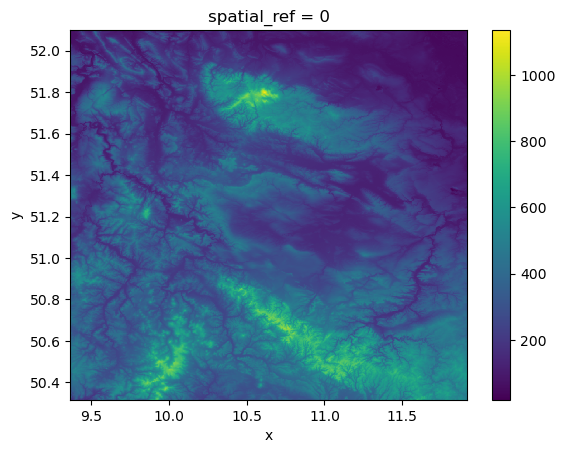

In [6]:
# Plot and visualize the raw DEM file by loading it in python as an xarray DataSet

# Path to DEM
dem_raw_file = os.path.join(os.environ["PATH_DATA_SRC"], "static/morph/dem.asc")

# Load DEM as xarray
dem_xr = rxr.open_rasterio(dem_raw_file, masked=True).squeeze(drop=True)

# Visualize the DEM
dem_xr.plot()
# plt.show()

#### Why fill DEMS? 
> DEMs often contain depressions or sinks, which are areas where water would artificially accumulate due to errors or noise in the data. 
>
> These depressions can interfere with hydrological analysis and other terrain-based processing tasks. 
>
> Therefore, it is necessary to identify and fill such depressions prior to further processing to ensure 
the DEM accurately represents the terrain and produces reliable results.


In [7]:
# ====== FILL THE DEM FILE =========

# the dem is now already loaded in python 
# You can easily fill a DEM file using the pyflwdir command as below:

# Convert to NumPy array
dem_np = dem_xr.values.squeeze()  # 2D numpy array

# Fill depressions using pyflowdir
dem_filled_np, filled_mask = pfd.dem.fill_depressions(dem_np)

print("DEM filled successfully!")

DEM filled successfully!


In [23]:
dem_filled_np

array([[ 70.,  70.,  70., ...,  56.,  57.,  56.],
       [ 68.,  67.,  68., ...,  58.,  57.,  57.],
       [ 67.,  67.,  67., ...,  58.,  59.,  58.],
       ...,
       [242., 230., 214., ..., 492., 486., 488.],
       [214., 201., 190., ..., 508., 505., 500.],
       [189., 182., 181., ..., 507., 506., 506.]], shape=(913, 1305))

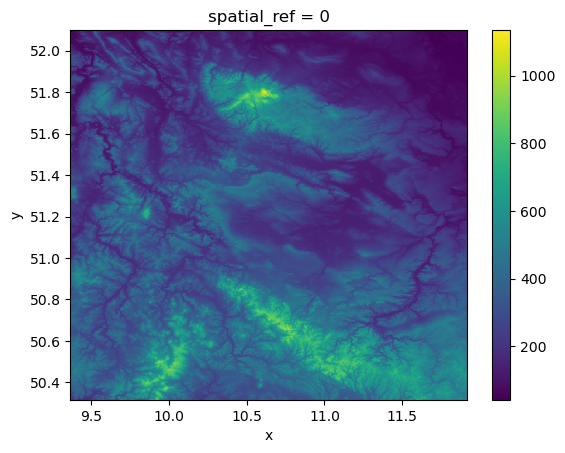

In [8]:
# convert back to xarray which preserves metadata
dem_filled_xr = xr.DataArray(dem_filled_np,
                           coords=dem_xr.coords,
                           dims=dem_xr.dims,
                           attrs=dem_xr.attrs)

# >>>>>> Exercise 1.1 <<<<<<<<

# Visualize the filled DEM

# Visualize the DEM
dem_filled_xr.plot()
# plt.show()


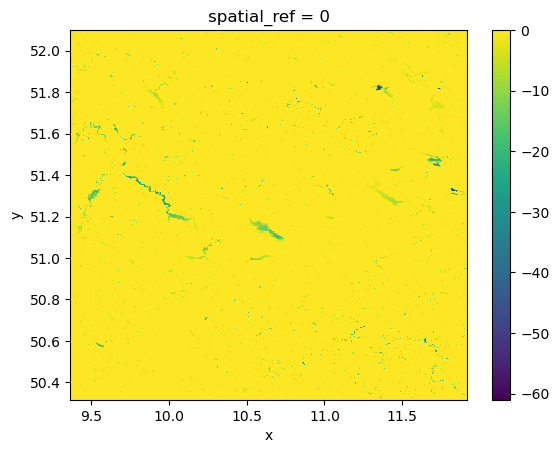

In [9]:
# >>>>>> Exercise 1.2 <<<<<<<<

# Visualize the difference between the raw and filled DEM
difference_xr = dem_xr - dem_filled_xr
# difference_xr


# Visualize the DEM
difference_xr.plot()
plt.show()


In [10]:
# Include nodata attribute
dem_filled_xr.rio.write_nodata(-9999, inplace=True)

# The DEM is currently still in the raw extent and needs to be clipped later. 
# For now save these intermediate files to PATH_WORK

# Save as ASCII
filled_dem_path = Path(os.environ["PATH_WORK"]) / "full_extent/static/morph/dem_filled.asc"
filled_dem_path.parent.mkdir(exist_ok=True, parents=True)
dem_filled_xr.rio.to_raster(filled_dem_path, driver="AAIGrid")

print("DEM saved as ASCII file!")

DEM saved as ASCII file!


In [11]:
%%bash

# Inspect using the head command
head -6 ${PATH_WORK}/full_extent/static/morph/dem_filled.asc

ncols        1305
nrows        913
xllcorner    9.367187500000
yllcorner    50.316406250000
cellsize     0.001953125000
NODATA_value -9999


--------------
#### >>> Flow Direction

In [12]:
# ====== GENERATE FLOW DIRECTION & FLOW ACCUMULATION =========


# >>>>>> Exercise 1.3 <<<<<<<<
# Look for pyflwdir command to generate fdir_raw.asc from dem_raw_filled.asc

# Compute flow direction (D8 nomenclature for mHM)
fdir_pfd = pfd.from_dem(dem_filled_np) # using np and not xr object as the function needs numpy array as input

# convert the pyflwdir object to numpy array
fdir_np = fdir_pfd.to_array()

# convert back to xarray which preserves metadata
fdir_xr = xr.DataArray(fdir_np,
                           coords=dem_xr.coords,
                           dims=dem_xr.dims,
                           attrs=dem_xr.attrs)

print("flow direction ready!")

flow direction ready!


**Hint**: `pyflwdir` website [[LINK]](https://deltares.github.io/pyflwdir/latest/quickstart.html). Find the correct command to derive flow direction from input dem. 

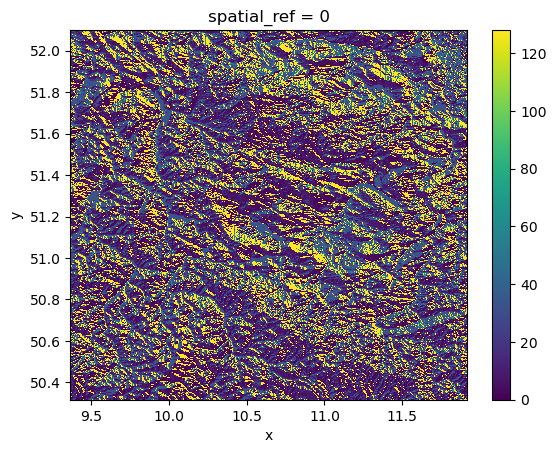

In [13]:
# Visualize the DEM
fdir_xr.plot()
plt.show()

In [61]:
fdir_xr

<xarray.DataArray (y: 913, x: 1305)> Size: 1MB
array([[  2,   4,   8, ...,   0,  16,   0],
       [  1,   2,   4, ...,  64,  32,  64],
       [128,   1,   2, ..., 128,  64,  32],
       ...,
       [  2,   2,   2, ..., 128, 128,  64],
       [  2,   2,   4, ..., 128,  64,  32],
       [  1,   1,   0, ..., 128, 128,  64]],
      shape=(913, 1305), dtype=uint8)
Coordinates:
  * y            (y) float64 7kB 52.1 52.1 52.09 52.09 ... 50.32 50.32 50.32
  * x            (x) float64 10kB 9.368 9.37 9.372 9.374 ... 11.91 11.91 11.92
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

In [13]:
np.unique(fdir_xr)

array([  0,   1,   2,   4,   8,  16,  32,  64, 128], dtype=uint8)

In [14]:
# Include nodata attribute
# 1 to 128 are the valid directions. 
# Storing -9999 would require signed integer data type. 
# The no data value for d8 is 247.



# Save as ASCII to $PATH_WORK/full_extent/static/morph/fdir.asc
fdir_asci_path = Path(os.environ["PATH_WORK"]) / "full_extent/static/morph/fdir.asc"
fdir_asci_path.parent.mkdir(exist_ok=True, parents=True)
fdir_xr.rio.to_raster(fdir_asci_path, driver="AAIGrid")



if Path(os.environ["PATH_WORK"], "full_extent/static/morph/fdir.asc").is_file():
    print("flow direction saved as ASCII file!")

flow direction saved as ASCII file!


In [15]:
%%bash

# Inspect using the head command

# Inspect using the head command
head -6 ${PATH_WORK}/full_extent/static/morph/fdir.asc


ncols        1305
nrows        913
xllcorner    9.367187500000
yllcorner    50.316406250000
cellsize     0.001953125000
2 4 8 8 8 8 2 4 8 8 8 8 8 16 16 4 8 8 16 16 16 8 0 16 16 0 16 16 16 16 16 16 16 16 16 16 16 16 1 1 0 16 1 1 0 1 1 1 1 1 1 1 0 16 16 1 1 1 1 1 0 1 0 16 8 16 16 16 16 16 8 8 16 16 16 16 16 16 16 16 16 2 2 2 2 2 4 2 2 2 2 4 8 8 8 8 8 8 1 1 1 2 1 1 1 2 1 2 2 2 1 1 1 1 1 0 16 16 1 0 1 1 0 1 0 16 16 16 1 1 1 1 1 2 2 2 4 8 8 8 8 8 8 4 1 2 4 1 2 2 1 2 2 2 2 2 2 1 0 1 0 16 16 16 16 16 1 1 1 2 2 2 2 2 1 1 0 16 16 16 16 16 0 16 16 16 16 1 0 16 2 2 1 0 16 16 1 0 1 0 16 1 1 0 16 16 16 8 8 8 2 4 8 8 8 8 8 8 8 8 8 16 16 16 16 16 16 16 16 8 2 2 2 4 8 8 16 16 16 16 8 8 8 8 8 8 2 2 4 8 8 8 8 8 8 8 1 1 1 1 1 1 1 1 1 2 2 2 2 4 8 8 8 8 8 8 2 2 2 2 2 2 2 1 0 1 0 16 16 16 1 1 0 16 16 16 1 1 1 0 16 16 1 0 16 1 0 16 16 1 1 1 1 1 1 1 0 1 1 1 1 2 1 1 1 1 0 1 0 16 8 8 8 16 16 16 16 1 0 16 8 8 8 8 8 8 8 2 4 8 8 4 8 2 4 8 4 8 4 8 2 1 0 16 8 8 8 16 16 16 16 0 16 1 0 16 16 16 16 16 16 16 16 1 1 0 16

--------------
#### >>> Flow Accumulation

Compute flow accumulation in number of upstream cells. 
For that you can take at the `pyflwdir` website [[LINK]](https://deltares.github.io/pyflwdir/latest/quickstart.html) to ind the correct command to derive flow accummulation.

**Hint**: search for upstream area

In [16]:

# >>>>>> Exercise 1.4 <<<<<<<<
# Look for pyflwdir command to generate facc.asc.

flac_pfd = fdir_pfd.upstream_area(unit = 'cell')

# Compute flow accumulation in number of upstream cells 
# flac_np = flac_pfd.to_array()
# flac_np
# Convert back to xarray which preserves metadata as we did with fdir
flac_xr = xr.DataArray(flac_pfd,
                           coords=dem_xr.coords,
                           dims=dem_xr.dims,
                           attrs=dem_xr.attrs)

print("flow acc ready!")


flow acc ready!


In [17]:
flac_xr

<xarray.DataArray (y: 913, x: 1305)> Size: 5MB
array([[  1,   1,   1, ...,  11,   1,   2],
       [  1,   6,   2, ...,   1,   7,   1],
       [  1,   2,  14, ...,   4,   1,   1],
       ...,
       [  1,   2,   3, ...,   3,   8,   1],
       [  1,   2,   3, ...,   1,   3,   3],
       [  1,   3, 706, ...,   2,   1,   1]],
      shape=(913, 1305), dtype=int32)
Coordinates:
  * y            (y) float64 7kB 52.1 52.1 52.09 52.09 ... 50.32 50.32 50.32
  * x            (x) float64 10kB 9.368 9.37 9.372 9.374 ... 11.91 11.91 11.92
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

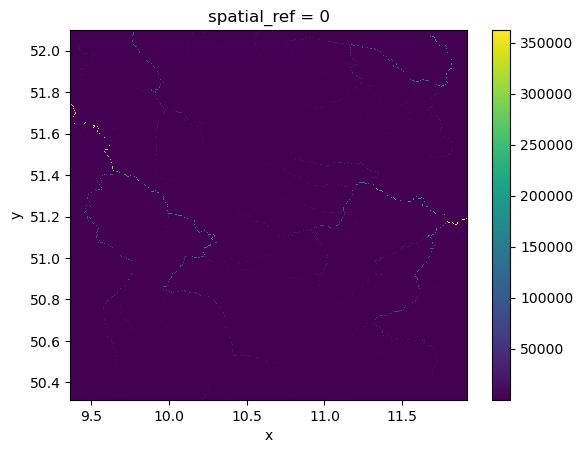

In [18]:
# Visualize the calculated flow accumulation
flac_xr.plot()
plt.show()


In [19]:
# Include nodata attribute
flac_xr.rio.write_nodata(-9999, inplace=True)


# Save as ASCII to $PATH_WORK/full_extent/static/morph/fdir.asc
facc_asci_path = Path(os.environ["PATH_WORK"]) / "full_extent/static/morph/facc.asc"
facc_asci_path.parent.mkdir(exist_ok=True, parents=True)
flac_xr.rio.to_raster(facc_asci_path, driver="AAIGrid")



if Path(os.environ["PATH_WORK"], "full_extent/static/morph/facc.asc").is_file():
    print("flow accumulation saved as ASCII file!")


flow accumulation saved as ASCII file!


In [21]:
%%bash

# Inspect using the head command
head -6 ${PATH_WORK}/full_extent/static/morph/facc.asc

ncols        1305
nrows        913
xllcorner    9.367187500000
yllcorner    50.316406250000
cellsize     0.001953125000
NODATA_value -9999


--------------
#### >>> Slope & Aspect

Generate Slope and Aspect from the dem file by using `gdaldem`. 
GDAL website [[LINK]](https://gdal.org/en/stable/programs/gdaldem.html#gdaldem). Find the correct command to derive slope and aspect from input dem. 

**Hint**: mHM needs slope in percentage rise.

In [20]:
%%bash


# >>>>>> Exercise 1.5 <<<<<<<<
# Look for gdal command to generate slope.asc (percentage rise) from dem.asc

gdaldem slope ${PATH_DATA_SRC}/static/morph/dem.asc ${PATH_WORK}/full_extent/static/morph/slope.asc -s 111200.0 -p -of AAIGrid




0...10...20...30...40...50...60...70...80...90...100 - done.


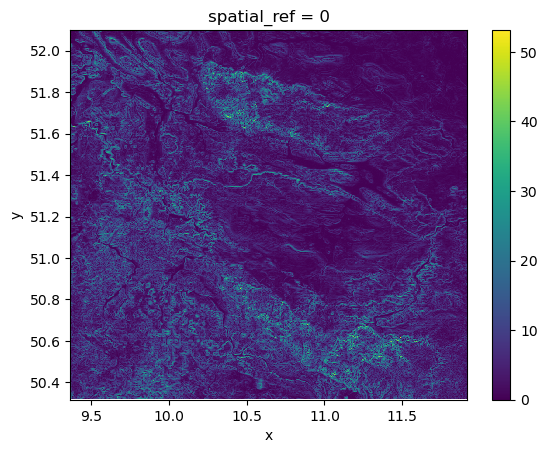

In [21]:
# visualize the slope

# Path to slope
slope_file = os.path.join(os.environ["PATH_WORK"], "full_extent/static/morph/slope.asc")

# Load slope as xarray
slope_xr = rxr.open_rasterio(slope_file, masked=True).squeeze(drop=True)

# Visualize the slope
slope_xr.plot()
plt.show()

In [22]:
%%bash


# >>>>>> Exercise 1.6 <<<<<<<<
# Look for gdal command to generate aspect.asc from dem.asc

gdaldem aspect "${PATH_DATA_SRC}/static/morph/dem.asc" \
               "${PATH_WORK}/full_extent/static/morph/aspect.asc" \
               -of AAIGrid


0...10...20...30...40...50...60...70...80...90...100 - done.


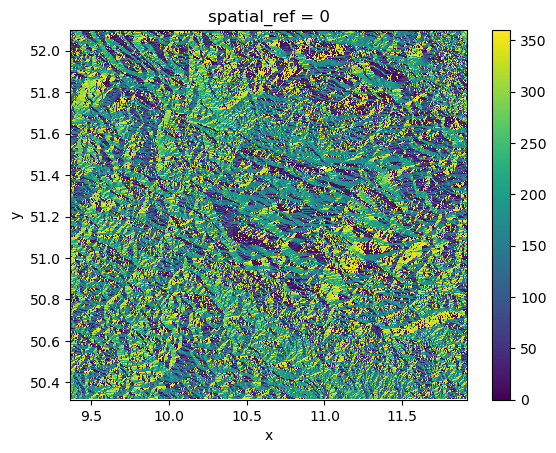

In [23]:
# visualize the aspect

# Path to aspect
aspect_file = os.path.join(os.environ["PATH_WORK"], "full_extent/static/morph/aspect.asc")

# Load aspect as xarray
aspect_xr = rxr.open_rasterio(aspect_file, masked=True).squeeze(drop=True)

# Visualize the aspect
aspect_xr.plot()
plt.show()


---------
### 2. **Catchment Shape and Gauge Locations** [`Morphology`, $\ell_0$]
--------------------------------

**Given**: 
- file: `dem_filled.asc` (filled, full extent)
- path: `work_dir/full_extent/static/morph/`
- files: `6340200_Q_Day.Cmd.txt` & `6340220_Q_Day.Cmd.txt` (GRDC streamflow observations)
- path: `data_raw/observation/streamflow/`

**Target**: 
- files: `dem.asc` (masked), and `idgauges.asc`
- path: `data_processed/static/morph/`


#### Do input data need to be in the shape of the catchment?
> All the input data in mHM have a common rectangular extent since the data are netCDFs and ASCIIs i.e., rasters. Depending on need, there are two ways to control the modeling extent in mHM.
>
> `A`. One can model the whole rectangular extent. This is useful for, say, inclusion of coastal areas in the model. Inclusion of full coastal line is not possible
if one were to mask the data for catchment/s.
>
> `B`. One can model only the catchment/s or area of interest. For this, it is sufficient to mask only the `dem.asc` file, while the remaining data files can be left unmasked. Therefore, `dem.asc` plays an additonal role of mask in mHM.

#### How does mHM determine the location of observation gauges?
> The flow accumulation file (`facc.asc`) is the river information input at $\ell_0$ in mHM.
>
> The observation gauges, thus, need to be located on the correct river i.e., correct $\ell_0$ cell corresponding to the `facc.asc`. Error of one cell across the actual gauge location on river might, understandably, induce large errors. Therefore, correctly snapping the gauge location to `facc.asc` is critical for mHM.
>
> The snapped location/s of gauge/s is to be stored in a different ASCII file named `idgauges.asc`. This is basically an empty file i.e. -9999 everywhere, except for the $\ell_0$ cell locations of the gauges where the gauge ID (integer) should be saved.

#### How to delineate a catchment with mhm-tools?
> There are multiple procedures that can be applied for the generation of catchment shape and snapping the gauge locations to flow accummulation. 
> Procedure based on GIS user interface is common, yet manual. The one we propose for you today is an inhouse software called mhm-tools which is based on the [pyflwdir package](https://deltares.github.io/pyflwdir/latest/index.html) that you already used above.
> mhm-tools is already included in the conda environment provided to you and can be run in the bash comandline.
>
> The mhm-tools carry out automated optimisation where the gauge coordinates are iterated on the input flow accummulation, within user-controlled search radius (`max_distance_cells`) from the input gauge coordinates (`gauge_coords`).
>
> In each iteration, the area of the catchment generated is compared with the input catchment area at the gauge (`ref_catchment_area`) while the maximum relative error that is allowed is provided as `max_error`.
>
> The location and the catchment which give the minimum catchment area error is the final output. After that the catchment is delineated from the flow direction and the sum of all catchment cell sizes is compared to the provided catchment area as a sanity check. 
> 
> mhm-tools saves the a basin_ids.nc file that contains fdir and facc, information, a mask file that contains the catchment mask as boolinans and a location raster as `idgauges.asc` that is needed for mhm runs. For the last one you must also provide the `gauge_id`.

#### **Excercise 2**: Prepare the catchment shape and gauge location data
--------------------------------

#### mhm catchment delineation with create_catchment


- You have two observation gauge stations within the same catchment. 

- Delineate the catchment containing both the gauges. 

- Use the delineated shape to mask the `dem.asc`. 

- Also snap the gauges correctly to generate `idgauges.asc`.

- The `catchment area` and `coordinates` of the gauges can be found in their corresponding raw files are located at `data_raw/observation/streamflow/`




--------------
#### >>> Catchment Delineation

In [25]:
# >>>>>> Exercise 2.1 <<<<<<<<

# Decide on the IDs to be used for the two catchments.
# For both catchments we will export the IDs so they can be used later on

%env ID1 = 6340200
%env ID2 = 6340220

env: ID1=6340200
env: ID2=6340220


In [26]:
%%bash

# >>>>>> Exercise 2.2 <<<<<<<<

# Collect the catchment area and coordinates information for the two gauges. 

# catchment 1
CATCHMENT_AREA=6218.0
LAT=51.226506
LON=11.684707

# Set the meteorological resolution of ERA5 in decimal degrees
METEO_RES=0.25

# use mhm-tools to delineate the catchment mask and generate the gauge location map i.e., idgauges.asc
mhm-tools -qq create_catchment -i ${PATH_WORK}/full_extent/static/morph/dem_filled.asc --var dem --gauge_coords=${LAT},${LON} --ref_catchment_area=${CATCHMENT_AREA} --max_distance_cells=10 --max_error=0.25 --gauge_id $ID1 -o ${PATH_WORK}/delin/$ID1/ --mask_file=${PATH_WORK}/delin/$ID1/mask.nc && echo "[mhm-tools > create_catchment] completed Successfully!"



[mhm-tools > create_catchment] completed Successfully!


> If you change the log-level you will get additonal information including how well the delineated catchment area fits the provided area. 
>
>
>The folder now contains three files: 
>```
>    basin_ids.nc
>    gauges_id.asc
>    mask.nc
>```
>Take a look at them. For the rest of the exercises you will only need the mask and the gauges_id file.
>
>The gauges_id file will be used as input to mhm so move it over to the final setup folder folder. 
>
>
>You can use this mask file and do all further cropping and masking with using the other tools in mhm-tools. But this does not cover the region that needs to be covered for your meteo grid to fit. For this workshop please continue with manual cropping. For this you can inspect one of the three files to find out the min and max longitude and latitude. Remember that netcdf files normally contain center cell coordinates but for cropping and for mHM header files you need the corner coordinates.
>
>If you have more than one gauge you need to do some additonal work. 
> 1. Run this also for the second gauge.
> 2. Now you need to check if one of the gauges describes a subcatchment of the other. For this check the extends from the mask file. Or the id gauges files. 

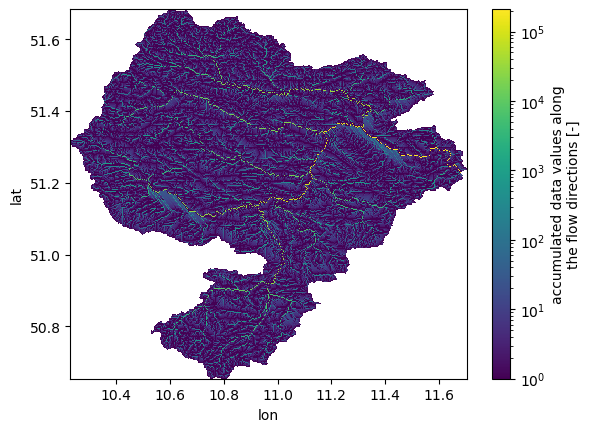

In [27]:
# >>>>>> Exercise 2.3 <<<<<<<<

# Visualize the catchment mask generated

# Path to mask file
basin_file_ID1 = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID1"], "basin_ids.nc")

# Load basin as xarray Dataset
basin_ds = xr.open_dataset(basin_file_ID1)

# Extract the data array
# If there's only one variable, this will grab it directly
uparea_grid_ID1 = basin_ds["uparea_grid"].squeeze(drop=True)

# Plot
uparea_grid_ID1.plot(norm=LogNorm())
plt.show()

In [23]:
# >>>>>> Exercise 2.4 (optional) <<<<<<<<

# Check that the basin delineation went well. 
# To see where the gauge is located 
# you can load your `facc.asc` file you created in Ex1.
# plot it and plot a dot for gauge you get from `idgauges.asc`
# Take care of the different extend of the two files.
# If you want you can also overlapp the `uparea_grid`
# from the `basin_ids.nc`file. 


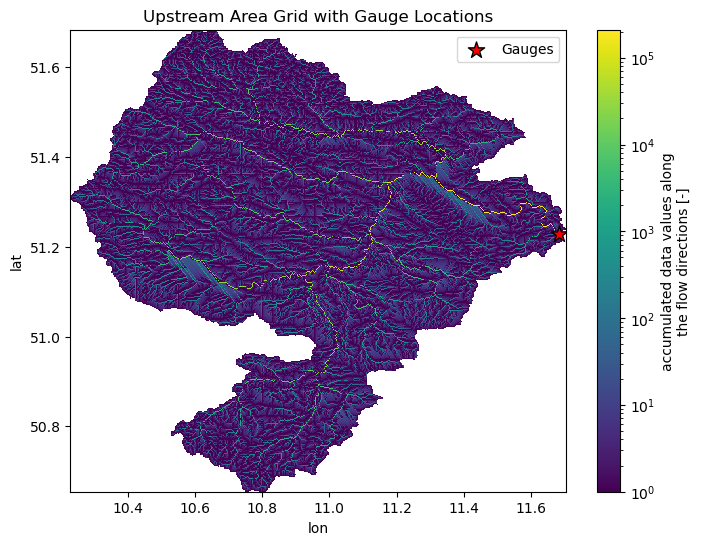

In [28]:
# >>>>>> Exercise 2.4 <<<<<<<<

# Path to basin file
basin_file_ID1 = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID1"], "basin_ids.nc")

# Load basin
basin_ds = xr.open_dataset(basin_file_ID1)
uparea_grid_ID1 = basin_ds["uparea_grid"].squeeze(drop=True)

# >>>>>> Add idgauges.ascii <<<<<<<<
gauges_file = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID1"], "idgauges.asc")

# Open gauges raster
gauges = xr.open_dataarray(gauges_file, engine='rasterio').squeeze()

# Find gauge cells (non-zero or positive values)
mask = gauges.values > 0
y, x = np.where(mask)

# Convert to coordinates
x_coords = gauges.x.values[x]
y_coords = gauges.y.values[y]

# Plot
plt.figure(figsize=(8, 6))
uparea_grid_ID1.plot(norm=LogNorm(), cmap='viridis')
plt.scatter(x_coords, y_coords, color='red', marker='*', s=150, edgecolor='black', label='Gauges')
plt.title("Upstream Area Grid with Gauge Locations")
plt.legend()
plt.show()


In [29]:
%%bash

# >>>>>> Exercise 2.5 <<<<<<<<

# catchment 2
CATCHMENT_AREA2=374.3
LAT2=51.257065
LON2=10.891464

# Set the meteorological resolution of ERA5 in decimal degrees
METEO_RES=0.25

# use mhm-tools to delineate the catchment mask and generate the gauge location map i.e., idgauges.asc
mhm-tools -qq create_catchment -i ${PATH_WORK}/full_extent/static/morph/dem_filled.asc --var dem --gauge_coords=${LAT2},${LON2} --ref_catchment_area=${CATCHMENT_AREA2} --max_distance_cells=10 --max_error=0.25 --gauge_id $ID2 -o ${PATH_WORK}/delin/$ID2/ --mask_file=${PATH_WORK}/delin/$ID2/mask.nc && echo "[mhm-tools > create_catchment] completed Successfully!"


[mhm-tools > create_catchment] completed Successfully!


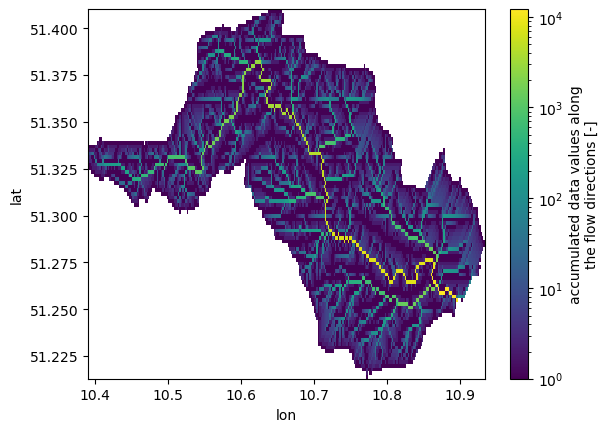

In [26]:
# >>>>>> Exercise 2.6 <<<<<<<<

# Visualize the catchment mask generated

# Path to mask file
basin_file_ID2 = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID2"], "basin_ids.nc")

# Load basin as xarray Dataset
basin2_ds = xr.open_dataset(basin_file_ID2)

# Extract the data array
# If there's only one variable, this will grab it directly
uparea_grid_ID2 = basin2_ds["uparea_grid"].squeeze(drop=True)

# Plot
uparea_grid_ID2.plot(norm=LogNorm())
plt.show()


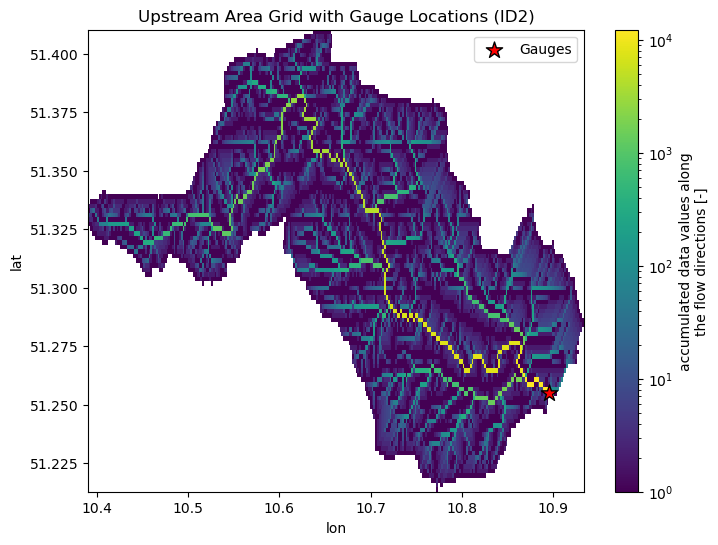

In [27]:
# >>>>>> Exercise 2.6 <<<<<<<<

# Visualize the catchment mask generated

# Path to basin file
basin_file_ID2 = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID2"], "basin_ids.nc")

# Load basin as xarray Dataset
basin2_ds = xr.open_dataset(basin_file_ID2)

# Extract the data array
uparea_grid_ID2 = basin2_ds["uparea_grid"].squeeze(drop=True)

# >>>>>> Add idgauges.ascii <<<<<<<<
gauges_file = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID2"], "idgauges.asc")

# Open gauges raster
gauges = xr.open_dataarray(gauges_file, engine='rasterio').squeeze()

# Find gauge cells (non-zero or positive values)
mask = gauges.values > 0
y, x = np.where(mask)

# Convert to coordinates
x_coords = gauges.x.values[x]
y_coords = gauges.y.values[y]

# Plot
plt.figure(figsize=(8, 6))
uparea_grid_ID2.plot(norm=LogNorm(), cmap='viridis')
plt.scatter(x_coords, y_coords, color='red', marker='*', s=150, edgecolor='black', label='Gauges')
plt.title("Upstream Area Grid with Gauge Locations (ID2)")
plt.legend()
plt.show()


In [42]:
# >>>>>> Exercise 2.7 <<<<<<<<

# How would the two catchments compare? Visualize by plotting them side-by-side.
# in matplotlib you can do that by using the subplots command: 
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# first_ds.plot(ax=ax[0]) or ax[0].plot(first_ds.values)
# second_ds.plot(ax=ax[1]) or ax[1].plot(second_ds.values)
# plt.tight_layout()
# plt.plot()

# bonus: allign the two datasets in a common latlon grid and plot them both on the same axis.


/tmp/ipykernel_3972/3465383129.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


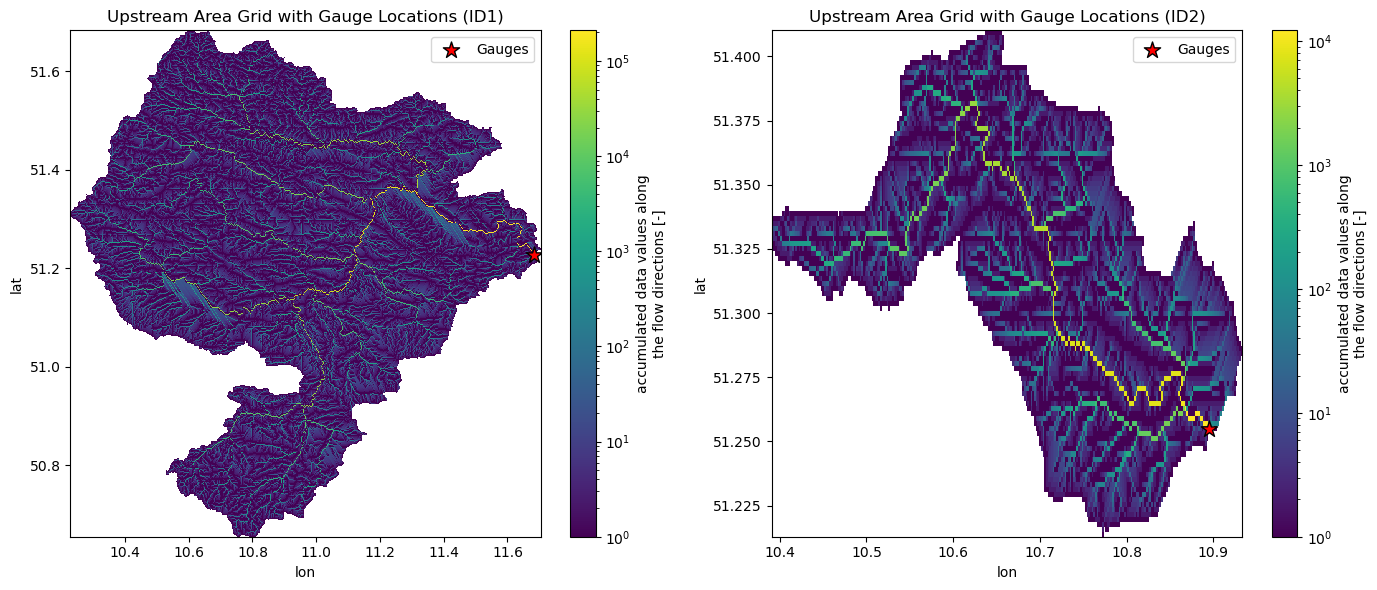

In [28]:
# >>>>>> Exercise 2.4 & 2.6 Combined <<<<<<<<
# ------------------ ID1 ------------------
basin_file_ID1 = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID1"], "basin_ids.nc")
basin_ds = xr.open_dataset(basin_file_ID1)
uparea_grid_ID1 = basin_ds["uparea_grid"].squeeze(drop=True)

gauges_file_ID1 = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID1"], "idgauges.asc")
gauges_ID1 = xr.open_dataarray(gauges_file_ID1, engine='rasterio').squeeze()

mask_ID1 = gauges_ID1.values > 0
y1, x1 = np.where(mask_ID1)
x_coords1 = gauges_ID1.x.values[x1]
y_coords1 = gauges_ID1.y.values[y1]

# ------------------ ID2 ------------------
basin_file_ID2 = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID2"], "basin_ids.nc")
basin_ds2 = xr.open_dataset(basin_file_ID2)
uparea_grid_ID2 = basin_ds2["uparea_grid"].squeeze(drop=True)

gauges_file_ID2 = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID2"], "idgauges.asc")
gauges_ID2 = xr.open_dataarray(gauges_file_ID2, engine='rasterio').squeeze()

mask_ID2 = gauges_ID2.values > 0
y2, x2 = np.where(mask_ID2)
x_coords2 = gauges_ID2.x.values[x2]
y_coords2 = gauges_ID2.y.values[y2]

# ------------------ Plot Both ------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for ID1
uparea_grid_ID1.plot(ax=axes[0], norm=LogNorm(), cmap='viridis')
axes[0].scatter(x_coords1, y_coords1, color='red', marker='*', s=150, edgecolor='black', label='Gauges')
axes[0].set_title("Upstream Area Grid with Gauge Locations (ID1)")
axes[0].legend()

# Plot for ID2
uparea_grid_ID2.plot(ax=axes[1], norm=LogNorm(), cmap='viridis')
axes[1].scatter(x_coords2, y_coords2, color='red', marker='*', s=150, edgecolor='black', label='Gauges')
axes[1].set_title("Upstream Area Grid with Gauge Locations (ID2)")
axes[1].legend()

plt.tight_layout()
plt.show()


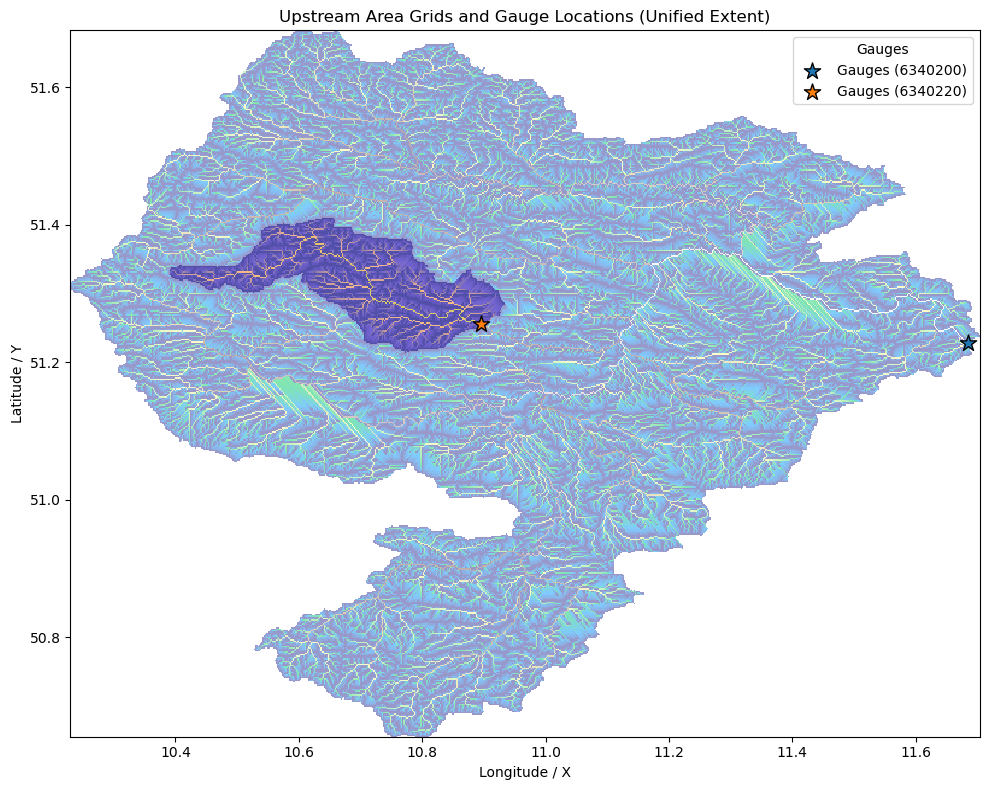

In [29]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# >>>>>> Combined Plot for Multiple Basins (Unified Extent, Gauge Legend Only) <<<<<<<<

# Basin IDs and color maps
basin_ids = [os.environ["ID1"], os.environ["ID2"]]  # add more if needed
cmaps = ['terrain', 'plasma', 'cividis', 'magma', 'viridis']

# ---- Helper to get coordinate names ----
def get_xy_names(da):
    coords = list(da.coords)
    x_name = next((c for c in coords if any(k in c.lower() for k in ['x', 'lon'])), None)
    y_name = next((c for c in coords if any(k in c.lower() for k in ['y', 'lat'])), None)
    return x_name, y_name

# ---- Load basins and compute unified extent ----
basin_data = []
xmins, xmaxs, ymins, ymaxs = [], [], [], []

for bid in basin_ids:
    ds = xr.open_dataset(os.path.join(os.environ["PATH_WORK"], "delin", bid, "basin_ids.nc"))
    da = ds["uparea_grid"].squeeze(drop=True)
    basin_data.append(da)

    x_name, y_name = get_xy_names(da)
    x_vals = da[x_name].values if x_name else np.arange(da.shape[-1])
    y_vals = da[y_name].values if y_name else np.arange(da.shape[-2])

    xmins.append(np.min(x_vals))
    xmaxs.append(np.max(x_vals))
    ymins.append(np.min(y_vals))
    ymaxs.append(np.max(y_vals))

xmin, xmax = min(xmins), max(xmaxs)
ymin, ymax = min(ymins), max(ymaxs)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 8))

for i, (bid, da) in enumerate(zip(basin_ids, basin_data)):
    da.plot(ax=ax, norm=LogNorm(), cmap=cmaps[i % len(cmaps)], alpha=0.5, add_colorbar=False)

    # Load gauges
    gauges_file = os.path.join(os.environ["PATH_WORK"], "delin", bid, "idgauges.asc")
    gauges = xr.open_dataarray(gauges_file, engine='rasterio').squeeze()
    mask = gauges.values > 0
    y, x = np.where(mask)

    gx_name, gy_name = get_xy_names(gauges)
    x_coords = gauges[gx_name].values[x] if gx_name else x
    y_coords = gauges[gy_name].values[y] if gy_name else y

    ax.scatter(
        x_coords, y_coords,
        marker='*', s=150, edgecolor='black',
        label=f'Gauges ({bid})'
    )

# ---- Final touches ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("Upstream Area Grids and Gauge Locations (Unified Extent)")
ax.set_xlabel("Longitude / X")
ax.set_ylabel("Latitude / Y")
ax.legend(title="Gauges", loc='best')

plt.tight_layout()
plt.show()


--------------
#### >>> Determination of the Model extents

In [43]:
%%bash
# >>>>>> Exercise 2.8 <<<<<<<<

# 1. Find the xmin, xmax, ymin, ymax for the model domain
# 2. Round up or down to the next meteo grid edge. But take care because era5 has it's cell centers at 0.25, 0.5, ... not it's edges.

gdalinfo ${PATH_WORK}/delin/$ID1/idgauges.asc
gdalinfo ${PATH_WORK}/delin/$ID2/idgauges.asc

Driver: AAIGrid/Arc/Info ASCII Grid
Files: /home/scizonarc/mhm_workshop/data/work_dir//delin/6340200/idgauges.asc
Size is 756, 527
Origin = (10.228515625000000,51.683593750000000)
Pixel Size = (0.001953125000000,-0.001953125000000)
Corner Coordinates:
Upper Left  (  10.2285156,  51.6835938) 
Lower Left  (  10.2285156,  50.6542969) 
Upper Right (  11.7050781,  51.6835938) 
Lower Right (  11.7050781,  50.6542969) 
Center      (  10.9667969,  51.1689453) 
Band 1 Block=756x1 Type=Int32, ColorInterp=Undefined
  NoData Value=-9999
Driver: AAIGrid/Arc/Info ASCII Grid
Files: /home/scizonarc/mhm_workshop/data/work_dir//delin/6340220/idgauges.asc
Size is 278, 101
Origin = (10.390625000000000,51.410156250000000)
Pixel Size = (0.001953125000000,-0.001953125000000)
Corner Coordinates:
Upper Left  (  10.3906250,  51.4101562) 
Lower Left  (  10.3906250,  51.2128906) 
Upper Right (  10.9335938,  51.4101562) 
Lower Right (  10.9335938,  51.2128906) 
Center      (  10.6621094,  51.3115234) 
Band 1 Block

In [46]:
# from osgeo import gdal
# import os

# def get_bbox_gdal(filepath):
#     """Extract bounding box using GDAL Python API"""
#     ds = gdal.Open(filepath)
#     if ds is None:
#         return None
    
#     geotransform = ds.GetGeoTransform()
#     xmin = geotransform[0]
#     ymax = geotransform[3]
#     xmax = xmin + geotransform[1] * ds.RasterXSize
#     ymin = ymax + geotransform[5] * ds.RasterYSize
    
#     ds = None  # Close dataset
#     return xmin, xmax, ymin, ymax

# # Get bounding boxes using proper path construction
# path1 = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID1"], "idgauges.asc")
# path2 = os.path.join(os.environ["PATH_WORK"], "delin", os.environ["ID2"], "idgauges.asc")

# bbox1 = get_bbox_gdal(path1)
# bbox2 = get_bbox_gdal(path2)

# # Combine domains
# xmin = min(bbox1[0], bbox2[0])
# xmax = max(bbox1[1], bbox2[1])
# ymin = min(bbox1[2], bbox2[2])
# ymax = max(bbox1[3], bbox2[3])

In [47]:
# xmin

In [30]:
from osgeo import gdal
import os
import math

def get_bbox_gdal(filepath):
    """Extract bounding box using GDAL Python API"""
    ds = gdal.Open(filepath)
    if ds is None:
        return None
    
    geotransform = ds.GetGeoTransform()
    xmin = geotransform[0]
    ymax = geotransform[3]
    xmax = xmin + geotransform[1] * ds.RasterXSize
    ymin = ymax + geotransform[5] * ds.RasterYSize
    
    ds = None  # Close dataset
    return xmin, xmax, ymin, ymax

# Get list of IDs (modify as needed)
IDS = [os.environ[f"ID{i}"] for i in range(1, 3)]  # Adjust range as needed

# Get bounding boxes for all paths
bboxes = []
for id_val in IDS:
    path = os.path.join(os.environ["PATH_WORK"], "delin", id_val, "idgauges.asc")
    bbox = get_bbox_gdal(path)
    if bbox:
        bboxes.append(bbox)
        print(f"{id_val}: {bbox}")

# Combine all domains
xmin = min(bbox[0] for bbox in bboxes)
xmax = max(bbox[1] for bbox in bboxes)
ymin = min(bbox[2] for bbox in bboxes)
ymax = max(bbox[3] for bbox in bboxes)

# Snap to ERA5 grid pattern: 0.125, 0.375, 0.625, 0.875, 1.125, ...
def snap_to_era5_center(value, snap_up=True):
    """Snap coordinate to ERA5 cell centers (0.125 + n*0.25)"""
    # Transform to 0.25 grid: subtract 0.125, divide by 0.25
    normalized = (value - 0.125) / 0.25
    
    if snap_up:
        snapped_normalized = math.ceil(normalized)
    else:
        snapped_normalized = math.floor(normalized)
    
    # Transform back: multiply by 0.25, add 0.125
    return snapped_normalized * 0.25 + 0.125

XMIN = snap_to_era5_center(xmin, snap_up=False)
XMAX = snap_to_era5_center(xmax, snap_up=True)
YMIN = snap_to_era5_center(ymin, snap_up=False)
YMAX = snap_to_era5_center(ymax, snap_up=True)

# Set as environment variables
%env XMIN={XMIN}
%env XMAX={XMAX}
%env YMIN={YMIN}
%env YMAX={YMAX}

print(f"\nCombined Domain: {XMIN}, {XMAX}, {YMIN}, {YMAX}")

6340200: (10.228515625, 11.705078125, 50.654296875, 51.68359375)
6340220: (10.390625, 10.93359375, 51.212890625, 51.41015625)
env: XMIN=10.125
env: XMAX=11.875
env: YMIN=50.625
env: YMAX=51.875

Combined Domain: 10.125, 11.875, 50.625, 51.875


/home/scizonarc/miniforge3/envs/mhm/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


--------------
#### >>> Formatting of Gauge location file

In [34]:
%%bash
# >>>>>> Exercise 2.9 <<<<<<<<

# Since we want to run both catchment as one mHM domain
# you need to merge the two files, maintaining the extent, 
# to arrive at the final idgauges.asc file.  
# You can achieve that using the following bash script:

# Adjust the extent of all the idgauges.asc files to full extent TIFF files
# Note: TIFF helps in cleaner execution with GDAL
mkdir -p ${PATH_WORK}/process/
# expand both idgauges.asc files to fill the whole extended domain
gdalwarp -overwrite -te ${XMIN} ${YMIN} ${XMAX} ${YMAX} ${PATH_WORK}/delin/${ID1}/idgauges.asc ${PATH_WORK}/process/idgauges_${ID1}.tif
gdalwarp -overwrite -te ${XMIN} ${YMIN} ${XMAX} ${YMAX} ${PATH_WORK}/delin/${ID2}/idgauges.asc ${PATH_WORK}/process/idgauges_${ID2}.tif
ls ${PATH_WORK}/process/idgauges_$ID2.tif
echo "All idgauges files are at full extent"

# merge all the full idgauges files to single idgauges file
gdal_merge.py -q -n -9999 -a_nodata -9999 -o ${PATH_WORK}/process/idgauges.tif ${PATH_WORK}/process/idgauges_*.tif
echo "All idgauges merged"

# Convert to ASCII
mkdir -p ${PATH_DATA_TGT}/static/morph/
gdal_translate ${PATH_WORK}/process/idgauges.tif ${PATH_DATA_TGT}/static/morph/idgauges.asc
echo "ASCII file produced"

echo "check if both ids are in the new file:"
grep -F --quiet -- "$ID1" "${PATH_DATA_TGT}/static/morph/idgauges.asc" && echo "  $ID1 found" || echo "  $ID1 not found"
grep -F --quiet -- "$ID2" "${PATH_DATA_TGT}/static/morph/idgauges.asc" && echo "  $ID2 found" || echo "  $ID2 not found"

Creating output file that is 896P x 640L.
Using internal nodata values (e.g. -9999) for image /home/scizonarc/mhm_workshop/data/work_dir//delin/6340200/idgauges.asc.
Copying nodata values from source /home/scizonarc/mhm_workshop/data/work_dir//delin/6340200/idgauges.asc to destination /home/scizonarc/mhm_workshop/data/work_dir//process/idgauges_6340200.tif.
Processing /home/scizonarc/mhm_workshop/data/work_dir//delin/6340200/idgauges.asc [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 896P x 640L.
Using internal nodata values (e.g. -9999) for image /home/scizonarc/mhm_workshop/data/work_dir//delin/6340220/idgauges.asc.
Copying nodata values from source /home/scizonarc/mhm_workshop/data/work_dir//delin/6340220/idgauges.asc to destination /home/scizonarc/mhm_workshop/data/work_dir//process/idgauges_6340220.tif.
Processing /home/scizonarc/mhm_workshop/data/work_dir//delin/6340220/idgauges.asc [1/1] : 0...10...20...30...40...50...60...70...

In [35]:
%%bash
head -6 "${PATH_DATA_TGT}/static/morph/idgauges.asc"
# head -6 "${PATH_DATA_TGT}/static/morph/idgauges.asc"
head -6 "${PATH_WORK}/delin/${ID1}/idgauges.asc"

gdalinfo "${PATH_WORK}/process/idgauges.tif"

ncols        896
nrows        640
xllcorner    10.125000000000
yllcorner    50.625000000000
cellsize     0.001953125000
NODATA_value -9999
ncols                756
nrows                527
xllcorner            10.228515625
yllcorner            50.654296875
cellsize             0.001953125
nodata_value         -9999
Driver: GTiff/GeoTIFF
Files: /home/scizonarc/mhm_workshop/data/work_dir//process/idgauges.tif
Size is 896, 640
Origin = (10.125000000000000,51.875000000000000)
Pixel Size = (0.001953125000000,-0.001953125000000)
Image Structure Metadata:
  INTERLEAVE=BAND
Corner Coordinates:
Upper Left  (  10.1250000,  51.8750000) 
Lower Left  (  10.1250000,  50.6250000) 
Upper Right (  11.8750000,  51.8750000) 
Lower Right (  11.8750000,  50.6250000) 
Center      (  11.0000000,  51.2500000) 
Band 1 Block=896x2 Type=Int32, ColorInterp=Gray
  NoData Value=-9999


--------------
#### >>> Masking of the DEM 

In [38]:
%%bash 
echo $ID1

6340200


In [36]:
%%bash

# >>>>>> Exercise 2.10 <<<<<<<<

# Since the dem.asc is used as the catchment mask in mHM runs 
# it needs to be masked with the mask from delineation. 

IN_DIR="${PATH_WORK}/full_extent/static/morph/"
echo "creating mask for catchment $ID1"

mhm-tools -q crop_mhm_setup -i $IN_DIR -o ${PATH_WORK}/delin/$ID1/ --file_name 'dem_filled.asc' -m ${PATH_WORK}/delin/$ID1/mask.nc --ncpus 1 --chunking  --available_mem 5Gb

# since we manually increased the domain size to fit the meteo grid but used the mask cropping and masking
# you need to expand the dem file just as you did with the idgauges.asc files.
# save it to: 
DEM_ID1_OUT=${PATH_DATA_TGT}/static/morph/dem.asc

# Expand the cropped DEM to the full domain extent
mkdir -p ${PATH_DATA_TGT}/static/morph/
gdalwarp -overwrite -te ${XMIN} ${YMIN} ${XMAX} ${YMAX} ${PATH_WORK}/delin/$ID1/dem_filled.asc ${PATH_DATA_TGT}/static/morph/dem.asc -of AAIGrid

echo "File written to ${PATH_DATA_TGT}/static/morph/dem.asc"

creating mask for catchment 6340200


2026-01-29 17:57:34,335 - mhm_tools.common.xarray_utils - WARNING - <class 'xarray.core.dataset.Dataset'> does not contain fitting coordinates. Trying again looking for dimensions


Creating output file that is 896P x 640L.
Using internal nodata values (e.g. -9999) for image /home/scizonarc/mhm_workshop/data/work_dir//delin/6340200/dem_filled.asc.
Copying nodata values from source /home/scizonarc/mhm_workshop/data/work_dir//delin/6340200/dem_filled.asc to destination .
0...10...20...30...40...50...60...70...80...90...100 - done.
File written to /home/scizonarc/mhm_workshop/data/data_processed//static/morph/dem.asc


**Question**: Why do you only need to do this for the dem of the 6340200 gauge?

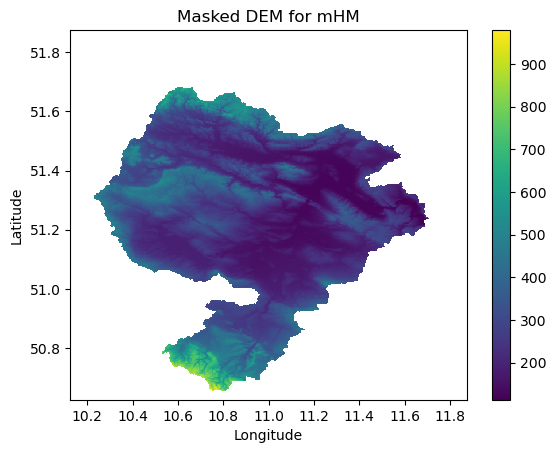

DEM extent: 10.125977 to 11.874023 (lon)
DEM extent: 50.625977 to 51.874023 (lat)
DEM shape: (640, 896)
DEM nodata value: nan


In [37]:
# >>>>>> Exercise 2.11 <<<<<<<<

# Visualize the masked DEM
# Plot and visualize the raw DEM file by loading it in python as an xarray DataSet

# Path to DEM
dem_mask_file = os.path.join(os.environ["PATH_DATA_TGT"], "static/morph/dem.asc")

# Check if file exists
if not os.path.exists(dem_mask_file):
    raise FileNotFoundError(f"DEM file not found: {dem_mask_file}. Please run Exercise 2.10 first.")

# Load DEM as xarray
dem_mask_xr = rxr.open_rasterio(dem_mask_file, masked=True).squeeze(drop=True)

# Visualize the DEM
dem_mask_xr.plot()
plt.title("Masked DEM for mHM")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

print(f"DEM extent: {dem_mask_xr.x.min().values:.6f} to {dem_mask_xr.x.max().values:.6f} (lon)")
print(f"DEM extent: {dem_mask_xr.y.min().values:.6f} to {dem_mask_xr.y.max().values:.6f} (lat)")
print(f"DEM shape: {dem_mask_xr.shape}")
print(f"DEM nodata value: {dem_mask_xr.rio.nodata}")


--------------
#### >>> Cropping of the Setup 
The files processed in section 1 are a larger extent than the processed DEM. 
Clip the files.
We propose you use one of two methods:
1. `gdalwarp` To find information use the `man gdalwarp` command or search the internet. 
2. `mhm-tools crop_mhm_setup` To find information please use the `-h` flag.

In [38]:
%%bash

# >>>>>> Exercise 2.12 <<<<<<<<

# Crop fdir, facc, slope, and aspect to the domain extent
# Use gdalwarp to crop all morphological files to the same extent as the DEM

IN_DIR=${PATH_WORK}/full_extent/static/morph/
OUT_DIR=${PATH_DATA_TGT}/static/morph/
mkdir -p ${OUT_DIR}

# Crop flow direction
gdalwarp -overwrite -te ${XMIN} ${YMIN} ${XMAX} ${YMAX} ${IN_DIR}/fdir.asc ${OUT_DIR}/fdir.asc -of AAIGrid

# Crop flow accumulation
gdalwarp -overwrite -te ${XMIN} ${YMIN} ${XMAX} ${YMAX} ${IN_DIR}/facc.asc ${OUT_DIR}/facc.asc -of AAIGrid

# Crop slope
gdalwarp -overwrite -te ${XMIN} ${YMIN} ${XMAX} ${YMAX} ${IN_DIR}/slope.asc ${OUT_DIR}/slope.asc -of AAIGrid

# Crop aspect
gdalwarp -overwrite -te ${XMIN} ${YMIN} ${XMAX} ${YMAX} ${IN_DIR}/aspect.asc ${OUT_DIR}/aspect.asc -of AAIGrid

echo "All morphological files cropped and saved to ${OUT_DIR}"



Creating output file that is 896P x 640L.
0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 896P x 640L.
Using internal nodata values (e.g. -9999) for image /home/scizonarc/mhm_workshop/data/work_dir//full_extent/static/morph//facc.asc.
Copying nodata values from source /home/scizonarc/mhm_workshop/data/work_dir//full_extent/static/morph//facc.asc to destination .
0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 896P x 640L.
Using internal nodata values (e.g. -9999) for image /home/scizonarc/mhm_workshop/data/work_dir//full_extent/static/morph//slope.asc.
Copying nodata values from source /home/scizonarc/mhm_workshop/data/work_dir//full_extent/static/morph//slope.asc to destination .
0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 896P x 640L.
Using internal nodata values (e.g. -9999) for image /home/scizonarc/mhm_workshop/data/work_dir//full_extent/static/morph//a

#### **Excercise 3**: 
--------------------------------
We will not do any processing of the other morphological input here except for clipping. Use `mhm-tools crop_mhm_setup` for this. For a help page of mhm-tools run `mhm-tools -h` if you need information about a specific tool and it's input run `mhm-tools <TOOL_NAME> -h`.
Now crop all the morphological files, lai files to the domain extend you fixed above. If you prefer to do so you can also use GDAL and CDO for this task.

**Given**: 
- file: `soil_class.asc`, `geology_class.asc`, `lc.asc`(full extent)
- path: `data_raw/static/morph/`
- files: `lai.nc` (full extent)
- path: `data_raw/lai/`

**Target**: 
- file: `soil_class.asc`, `geology_class.asc`, `lc.asc`(clipped)
- path: `data_processed/static/morph/`
- files: `lai.nc` (clipped)
- path: `data_processed/lai/`


In [39]:
%%bash

# >>>>>> Exercise 3.1 <<<<<<<<

# Clip the soil, geology, land cover
# Note: Do not forget to copy the class definition files to the target directory

IN_DIR=${PATH_DATA_SRC}/static/morph/
OUT_DIR=${PATH_DATA_TGT}/static/morph/
mkdir -p ${OUT_DIR}

# Crop soil class
gdalwarp -overwrite -te ${XMIN} ${YMIN} ${XMAX} ${YMAX} ${IN_DIR}/soil_class.asc ${OUT_DIR}/soil_class.asc -of AAIGrid

# Crop geology class
gdalwarp -overwrite -te ${XMIN} ${YMIN} ${XMAX} ${YMAX} ${IN_DIR}/geology_class.asc ${OUT_DIR}/geology_class.asc -of AAIGrid

# Crop land cover
gdalwarp -overwrite -te ${XMIN} ${YMIN} ${XMAX} ${YMAX} ${IN_DIR}/lc.asc ${OUT_DIR}/lc.asc -of AAIGrid

# Copy class definition files if they exist
if [ -f "${IN_DIR}/soil_class.txt" ]; then
    cp ${IN_DIR}/soil_class.txt ${OUT_DIR}/
fi
if [ -f "${IN_DIR}/geology_class.txt" ]; then
    cp ${IN_DIR}/geology_class.txt ${OUT_DIR}/
fi
if [ -f "${IN_DIR}/lc_class.txt" ] || [ -f "${IN_DIR}/lc.txt" ]; then
    cp ${IN_DIR}/lc*.txt ${OUT_DIR}/ 2>/dev/null || true
fi

echo "Soil, geology, and landcover files cropped and saved to ${OUT_DIR}"

# >>>>>> Exercise 3.2 <<<<<<<<

# Clip the LAI data 
# LAI needs a header.txt file in its target folder that contains the grid information
IN_DIR=${PATH_DATA_SRC}/lai/
OUT_DIR=${PATH_DATA_TGT}/lai/
mkdir -p ${OUT_DIR}

# Use mhm-tools to crop LAI netCDF file
mhm-tools -q crop_mhm_setup -i ${IN_DIR} -o ${OUT_DIR} --file_name 'lai.nc' --lon_min ${XMIN} --lon_max ${XMAX} --lat_min ${YMIN} --lat_max ${YMAX} --create_header

echo "LAI file cropped and saved to ${OUT_DIR}"





Creating output file that is 896P x 640L.
Using internal nodata values (e.g. -9999) for image /home/scizonarc/mhm_workshop/data/data_raw//static/morph//soil_class.asc.
Copying nodata values from source /home/scizonarc/mhm_workshop/data/data_raw//static/morph//soil_class.asc to destination .
0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 896P x 640L.
Using internal nodata values (e.g. -9999) for image /home/scizonarc/mhm_workshop/data/data_raw//static/morph//geology_class.asc.
Copying nodata values from source /home/scizonarc/mhm_workshop/data/data_raw//static/morph//geology_class.asc to destination .
0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 896P x 640L.
Using internal nodata values (e.g. 255) for image /home/scizonarc/mhm_workshop/data/data_raw//static/morph//lc.asc.
Copying nodata values from source /home/scizonarc/mhm_workshop/data/data_raw//static/morph//lc.asc to destination .
0...10...20...

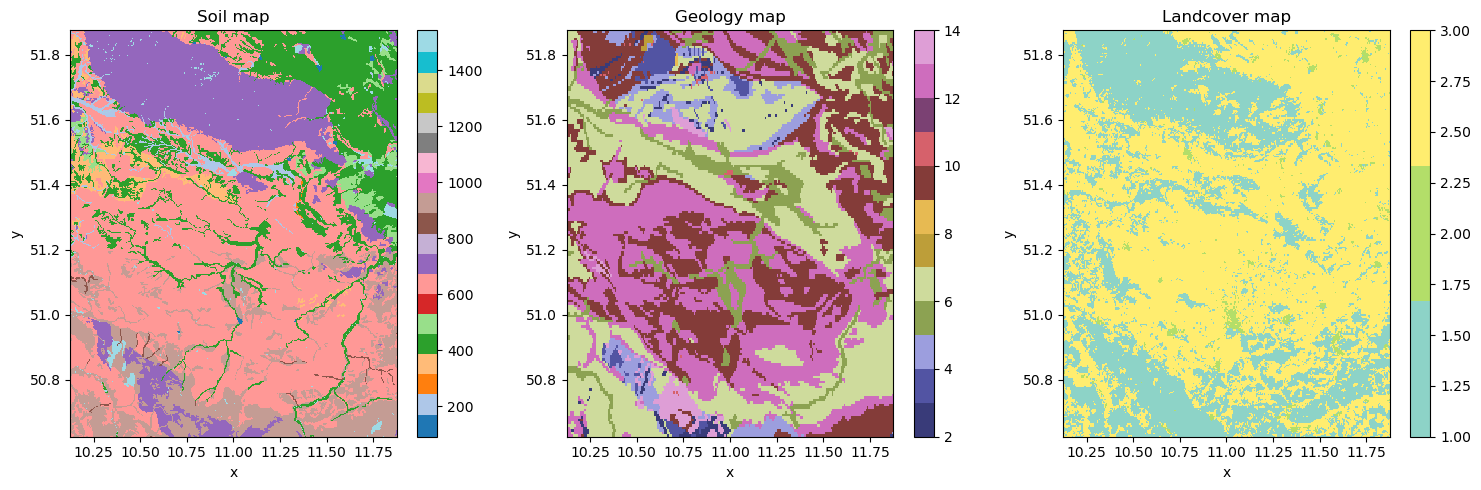

In [40]:
# >>>>>> Exercise 3.3 <<<<<<<<

# Visualize the clipped static maps of soil, geology, and landcover

# Path to clipped files
soil_clipped_file = os.path.join(os.environ["PATH_DATA_TGT"], "static/morph/soil_class.asc")
geol_clipped_file = os.path.join(os.environ["PATH_DATA_TGT"], "static/morph/geology_class.asc")
lcov_clipped_file = os.path.join(os.environ["PATH_DATA_TGT"], "static/morph/lc.asc")

# Load clipped files as xarray Dataset
soil_clipped = rxr.open_rasterio(soil_clipped_file, masked=True).squeeze()
geol_clipped = rxr.open_rasterio(geol_clipped_file, masked=True).squeeze()
lcov_clipped = rxr.open_rasterio(lcov_clipped_file, masked=True).squeeze()

# Define a discrete colormap with enough colors for your class count
soil_cmap = plt.get_cmap("tab20", len(np.unique(soil_clipped)))
geol_cmap = plt.get_cmap("tab20b", len(np.unique(geol_clipped)))
lcov_cmap = plt.get_cmap("Set3", len(np.unique(lcov_clipped)))

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

soil_clipped.plot(ax=axes[0], cmap=soil_cmap, add_colorbar=True)
axes[0].set_title("Soil map")

geol_clipped.plot(ax=axes[1], cmap=geol_cmap, add_colorbar=True)
axes[1].set_title("Geology map")

lcov_clipped.plot(ax=axes[2], cmap=lcov_cmap, add_colorbar=True)
axes[2].set_title("Landcover map")

plt.tight_layout()
plt.show()


### 4. **Generate the relationship between model resolution to morphology** [`Latlon file`]
--------------------------------
A latlon file contains the grid information on the different model resolutions (morphological input L0, mHM simulation L1, routing L11 and meteological input L2). You can create a latlon file using the mhm-tools. 
First check what input you need to create a latlon file. Are the required arguments enough in your case or do you need to also provide optional arguments?

In [41]:
%%bash
# mhm-tools latlon -h
head -6 ${PATH_DATA_TGT}/static/morph/dem.asc

ncols        896
nrows        640
xllcorner    10.125000000000
yllcorner    50.625000000000
cellsize     0.001953125000
NODATA_value -9999


The header files you need to provide are structured the same way as the headers of ascii files:
```
ncols          NCOLS 
nrows          NROWS
xllcorner      XLLCORNER
yllcorner      YLLCORNER
cellsize       CELLSIZE
NODATA_value   -9999
```
You have to make sure that the lower left corners and the uper right corners of all grids are the same such that they completely overlapp. The corser grids also need to have a resolution that is an integer multiple of finer grids. 
This is also the reason we changed adjusted the extend of the morphological grid such that its corners are the same as the corners of the era5 meteo data grid.

#### **Excercise 4**: 
--------------------------------
Create all the input that you need and create the latlon file using the mhm-tools. 

In [53]:
%%bash
mhm-tools latlon -h

usage: mhm-tools latlon [-h] -D LEVEL0 -H LEVEL1 [-R LEVEL11] [-M LEVEL2]
                        [-c CRS] [-d DTYPE] [-x {0,1,2,3,4,5,6,7,8,9}] [-b]
                        [--h0 H0] [--h1 H1] [--h11 H11] [--h2 H2]
                        [-o OUT_FILE]

Create the latlon.nc file required for mHM.

The latlon file contains the lat-lon information for 3 levels in mHM:
Level-0 (DEM), Level-1 (hydrology) and Level-11 (routing).
All levels will be checked for compatibility including Level-2 (meteo).
Level-0 can be given as a file or a dictionary containing an ascii grid
header. Other levels can then be given by only a cell-size and will be
determined from Level-0.

options:
  -h, --help            show this help message and exit
  -R LEVEL11, --level11 LEVEL11
                        Level-11 (routing) information. Either an ascii
                        (header) file, a dictionary containing the header
                        information or a cell-size to determine information
           

In [57]:
%%bash
# mhm-tools latlon -h

# >>>>>> Exercise 4 <<<<<<<<
# Create latlon file that connects model resolution to morphology

# Create header files directory for latlon tool
mkdir -p ${PATH_WORK}/headers/

# Create header file for L0 (morphological grid) from dem.asc - keep as is
head -6 ${PATH_DATA_TGT}/static/morph/dem.asc > ${PATH_WORK}/headers/l0_header.txt

# Create header file for L1 (hydrological simulation grid)
# Read L0 header and modify: same xll/yllcorner, cellsize * 4, adjust dimensions
python3 << PYEOF
import re

# Read L0 header
with open('${PATH_WORK}/headers/l0_header.txt', 'r') as f:
    l0_lines = f.readlines()

# Parse L0 header values
l0_values = {}
for line in l0_lines:
    line = line.strip()
    if 'ncols' in line.lower():
        l0_values['ncols'] = int(re.search(r'\d+', line).group())
    elif 'nrows' in line.lower():
        l0_values['nrows'] = int(re.search(r'\d+', line).group())
    elif 'xllcorner' in line.lower():
        l0_values['xllcorner'] = float(re.search(r'[\d.]+', line).group())
    elif 'yllcorner' in line.lower():
        l0_values['yllcorner'] = float(re.search(r'[\d.]+', line).group())
    elif 'cellsize' in line.lower():
        l0_values['cellsize'] = float(re.search(r'[\d.]+', line).group())
    elif 'nodata' in line.lower():
        l0_values['nodata'] = re.search(r'-?\d+', line).group()

# Create L1 header: same xll/yllcorner, cellsize * 4, adjust dimensions
l1_cellsize = l0_values['cellsize'] * 128
l1_ncols = int(l0_values['ncols'] / 128)
l1_nrows = int(l0_values['nrows'] / 128)

# Write L1 header
with open('${PATH_WORK}/headers/l1_header.txt', 'w') as f:
    f.write(f"ncols         {l1_ncols}\n")
    f.write(f"nrows         {l1_nrows}\n")
    f.write(f"xllcorner     {l0_values['xllcorner']}\n")
    f.write(f"yllcorner     {l0_values['yllcorner']}\n")
    f.write(f"cellsize      {l1_cellsize}\n")
    f.write(f"NODATA_value  {l0_values['nodata']}\n")

print(f"L1 header created: cellsize={l1_cellsize}, ncols={l1_ncols}, nrows={l1_nrows}")
PYEOF

# Create header file for L11 (routing grid) - same as L1 in this case
cp ${PATH_WORK}/headers/l1_header.txt ${PATH_WORK}/headers/l11_header.txt

# Create header file for L2 (meteorological grid) from pre.nc header
# head -6 ${PATH_DATA_TGT}/meteo/pre/header.txt > ${PATH_WORK}/headers/l2_header.txt

# Create latlon file using mhm-tools
# -D for Level 0, -H for Level 1, -R for Level 11, -M for Level 2
mhm-tools latlon \
    -D ${PATH_WORK}/headers/l0_header.txt \
    -H ${PATH_WORK}/headers/l1_header.txt \
    -R ${PATH_WORK}/headers/l11_header.txt \
    -o ${PATH_DATA_TGT}/latlon.nc

    # -M ${PATH_WORK}/headers/l2_header.txt \

echo "Latlon file created at ${PATH_DATA_TGT}/latlon.nc"




L1 header created: cellsize=0.25, ncols=7, nrows=5


2026-01-29 19:00:11,285 - mhm_tools - INFO - Steam Handler set to log_level INFO
2026-01-29 19:00:11,434 - mhm_tools.common.file_handler - INFO - Writing file to /home/scizonarc/mhm_workshop/data/data_processed/latlon.nc
2026-01-29 19:00:11,434 - mhm_tools.common.file_handler - INFO - <xarray.Dataset> Size: 5MB
Dimensions:  (yc_l0: 640, xc_l0: 896, yc_l1: 5, xc_l1: 7, yc_l11: 5, xc_l11: 7)
Coordinates:
  * yc_l0    (yc_l0) float32 3kB 51.87 51.87 51.87 51.87 ... 50.63 50.63 50.63
  * xc_l0    (xc_l0) float32 4kB 10.13 10.13 10.13 10.13 ... 11.87 11.87 11.87
  * yc_l1    (yc_l1) float32 20B 51.75 51.5 51.25 51.0 50.75
  * xc_l1    (xc_l1) float32 28B 10.25 10.5 10.75 11.0 11.25 11.5 11.75
  * yc_l11   (yc_l11) float32 20B 51.75 51.5 51.25 51.0 50.75
  * xc_l11   (xc_l11) float32 28B 10.25 10.5 10.75 11.0 11.25 11.5 11.75
    lat_l0   (yc_l0, xc_l0) float32 2MB 51.87 51.87 51.87 ... 50.63 50.63 50.63
    lon_l0   (yc_l0, xc_l0) float32 2MB 10.13 10.13 10.13 ... 11.87 11.87 11.87
    lat 

Latlon file created at /home/scizonarc/mhm_workshop/data/data_processed//latlon.nc


### 5. **Prepare the meteorological forcings** [`Meteorology`, $\ell_2$]
--------------------------------

#### **Excercise 5**: 
--------------------------------

Check the [mhm documentation](https://mhm-ufz.org/docs/) to find out how your meteo data must look.

Inspect the meta data of your raw meteo files. You can for example use `cdo infon`, `cdo sinfon`, `ncdump -h` for this. 

Now write a bash, python or R script that processes the meteo data such that in the end you have a folder structure that looks like this and the files are mhm readable. If you have to convert units or aggregate temporaly take extra care whether they are fluxes or states. 

```
meteo:
--- pre:
--- --- pre.nc
--- temp: 
--- --- tavg.nc
--- --- tmin.nc
--- --- tmax.nc 
```

Steps that might or might not be needed: 
	1	merge the files together into one
	2	crop to the domain you want
	3	create header file
	4	The variable names are hard coded in mHM so you might have to change them.
	5	Any data provided for mHM should be of the data type DOUBLE.
	6	Time must be in Integers. e.g hours since …, days since …
	7	Units must be correct
	8	No data value must be -9999.0 (if float)
	9	Latitude must be decreasing


We provide two solutions for precipitation: 
1. **Bash**: You can find a workflow in bash that works with or without the mhm-tools in `example_scripts_ex5/bash_precipiation_processing.sh`. If you want to use bash. Copy it below. Run it, analyize the results and write your own script for tmin, tmax and tavg.
2. **Python** You can find a python workflow based on xarray in `example_scripts_ex5/python_precipiation_processing.py`. Copy it below. Run it, analyize the results and write your own script for tmin, tmax and tavg.

In [43]:
%%bash
set -x
# example for pre
# 1. merge the files together into one:
mkdir -p "${PATH_WORK}/meteo/merged/pre/"
rm ${PATH_WORK}/meteo/merged/pre/*
cdo -w mergetime "${PATH_DATA_SRC}/meteo/pre/*.nc" "${PATH_WORK}/meteo/merged/pre/pre.nc"
# 2. crop to the domain you want. If you use mhm-tools you can also have it create the header file for you:
rm ${PATH_WORK}/meteo/cropped/pre/*
echo mhm-tools -v crop_mhm_setup -i "${PATH_WORK}/meteo/merged/pre/" -f="pre.nc" -o "${PATH_WORK}/meteo/cropped/pre/" --lon_min $XMIN --lon_max $XMAX --lat_min $YMIN --lat_max $YMAX --create_header
mhm-tools -v crop_mhm_setup -i "${PATH_WORK}/meteo/merged/pre/" -f="pre.nc" -o "${PATH_WORK}/meteo/cropped/pre/" --lon_min $XMIN --lon_max $XMAX --lat_min $YMIN --lat_max $YMAX --create_header
# alternatively if you do not have the mhm-tools: 
# ${PATH_WORK}/meteo/cropped/pre/
# cdo sellonlatbox,$XMIN,$XMAX,$YMIN,$YMAX ${PATH_WORK}/meteo/merged/pre/pre.nc ${PATH_WORK}/meteo/cropped/pre/pre.nc
# now manually create the header files

# check if the latitude is decreasing (YMAX to YMIN) if not you can flip it with cdo invertlat input.nc output.nc

# 3. The variable names are hard coded so they need to be pre, tavg, tmin, tmax
# mkdir -p ${PATH_WORK}/meteo/renamed_var/pre/
# cdo chname can not change a coordinate name but that is not necessary
mkdir -p ${PATH_WORK}/meteo/renamed/pre/
rm ${PATH_WORK}/meteo/renamed/pre/*
cdo chname,tp,pre ${PATH_WORK}/meteo/cropped/pre/pre.nc ${PATH_WORK}/meteo/renamed/pre/pre.nc
#ncrename -d valid_time,time ${PATH_WORK}/meteo/renamed_var/pre/pre.nc ${PATH_WORK}/meteo/renamed_coord/pre/pre.nc
#ncrename -O \
#  -d valid_time,time \
#  -v valid_time,time \
#  -v tp,pre \
#  "${PATH_WORK}/meteo/cropped/pre/pre.nc" \
#  "${PATH_WORK}/meteo/renamed/pre/pre.nc"

# 4. Any data provided for mHM should be of the data type DOUBLE. You should convert all data related to a variable VAR (e.g. tavg) with the following CDO command:
mkdir -p ${PATH_WORK}/meteo/double/pre/
rm ${PATH_WORK}/meteo/double/pre/*
cdo -b F64 selname,pre ${PATH_WORK}/meteo/renamed/pre/pre.nc ${PATH_WORK}/meteo/double/pre/pre.nc
# 5. The only exception here is the time, its data type has to be INTEGER. This can be changed with NCAP2:
mkdir -p ${PATH_WORK}/meteo/time_int/pre/
rm ${PATH_WORK}/meteo/time_int/pre/*
ncap2 -s "valid_time=int(valid_time)" ${PATH_WORK}/meteo/double/pre/pre.nc ${PATH_WORK}/meteo/time_int/pre/pre.nc

# 6. Set Fill_value and missing_value attributes to -9999
ncatted -O -a _FillValue,pre,o,d,-9999.0 ${PATH_WORK}/meteo/time_int/pre/pre.nc
ncatted -O -a missing_value,pre,m,d,-9999. ${PATH_WORK}/meteo/time_int/pre/pre.nc

# 7. Rename time
mkdir -p ${PATH_WORK}/meteo/rename_latlon_time/pre
# First convert to netCDF3 as ncrename has issues with netCDF4 
ncks -O -3 ${PATH_WORK}/meteo/time_int/pre/pre.nc ${PATH_WORK}/meteo/rename_latlon_time/pre/pre.nc3

# 8. Rename all vars and dimensions in one go
ncrename -O -v valid_time,time -d valid_time,time ${PATH_WORK}/meteo/rename_latlon_time/pre/pre.nc3 ${PATH_WORK}/meteo/rename_latlon_time/pre/pre_renamed.nc3
# ncrename -O -v longitude,lon -v latitude,lat -v valid_time,time -d longitude,lon -d latitude,lat -d valid_time,time ${PATH_WORK}/meteo/rename_latlon_time/pre/pre.nc3 ${PATH_WORK}/meteo/rename_latlon_time/pre/pre_renamed.nc3
# Convert back to netCDF4
ncks -O -4 ${PATH_WORK}/meteo/rename_latlon_time/pre/pre_renamed.nc3 ${PATH_WORK}/meteo/rename_latlon_time/pre/pre.nc4

# 9. the units for precipiation must be mm but era5 provides them in m 
mkdir -p ${PATH_WORK}/meteo/unit_conv/pre
cdo -setattribute,pre@units="mm" -mulc,1000 ${PATH_WORK}/meteo/rename_latlon_time/pre/pre.nc4 ${PATH_WORK}/meteo/unit_conv/pre/pre.nc

 
# 10. write the files to the final output
mkdir -p ${PATH_DATA_TGT}/meteo/pre
mv ${PATH_WORK}/meteo/unit_conv/pre/pre.nc ${PATH_WORK}/meteo/cropped/pre/header.txt ${PATH_DATA_TGT}/meteo/pre

# 11. compare the header with the dem check lower left corner and then if the ncols / nrows fit with the resolution ratio
head -6 ${PATH_DATA_TGT}/meteo/pre/header.txt
head -6 ${PATH_DATA_TGT}/static/morph/dem.asc

+ mkdir -p /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/pre/
+ rm /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/pre/pre.nc
+ cdo -w mergetime '/home/scizonarc/mhm_workshop/data/data_raw//meteo/pre/*.nc' /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/pre/pre.nc
+ rm /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/pre/pre.nc
+ echo mhm-tools -v crop_mhm_setup -i /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/pre/ -f=pre.nc -o /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/pre/ --lon_min 10.125 --lon_max 11.875 --lat_min 50.625 --lat_max 51.875 --create_header


mhm-tools -v crop_mhm_setup -i /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/pre/ -f=pre.nc -o /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/pre/ --lon_min 10.125 --lon_max 11.875 --lat_min 50.625 --lat_max 51.875 --create_header


+ mhm-tools -v crop_mhm_setup -i /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/pre/ -f=pre.nc -o /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/pre/ --lon_min 10.125 --lon_max 11.875 --lat_min 50.625 --lat_max 51.875 --create_header
2026-01-29 18:19:04,189 - mhm_tools - INFO - Steam Handler set to log_level DEBUG
2026-01-29 18:19:04,189 - mhm_tools.common.cli_utils - INFO - mem_string 5
2026-01-29 18:19:04,189 - mhm_tools.pre.crop_mhm_setup - DEBUG - Function 'crop_mhm_setup' called with the following arguments: 
  output_path: /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/pre/ 
  input_path: /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/pre/ 
  overwrite: True 
  lonslice: slice(10.125, 11.875, None) 
  latslice: slice(51.875, 50.625, None) 
  n_jobs: 1 
  filename: pre.nc 
  available_mem_gib: 5000000000 
  force_header_creation: True 
  chunking: False 
  no_cropping: False 

2026-01-29 18:19:04,189 - mhm_tools.pre.crop_mhm_setup - INFO -

ncols                7
nrows                5
xllcorner            10.125
yllcorner            50.625
cellsize             0.25
nodata_value         -9999.0


+ head -6 /home/scizonarc/mhm_workshop/data/data_processed//static/morph/dem.asc


ncols        896
nrows        640
xllcorner    10.125000000000
yllcorner    50.625000000000
cellsize     0.001953125000
NODATA_value -9999


In [ ]:
# # Copy the provided solution for precipitation here

# # helper functions
# def generate_bounds(
#     da: xr.DataArray,
#     bounds_dim: str = "bnds",
# ) -> xr.DataArray:
#     """Generate CF-compliant bounds for a coordinate DataArray."""
#     (dim,) = da.dims
#     diff = da.diff(dim)
#     lower = da - diff / 2
#     upper = da + diff / 2
#     bounds = xr.concat([lower, upper], dim=bounds_dim)
#     first_lower = bounds.isel({dim: 0}) - diff.isel({dim: 0})
#     first = first_lower.assign_coords({dim: da[dim][0]})
#     all_bounds = xr.concat([first, bounds], dim=dim)
#     return all_bounds.transpose()

# # create the output path
# output_path = Path(os.environ["PATH_DATA_TGT"])/"meteo/pre"
# output_path.mkdir(parents=True, exist_ok=True)

# # get the input files
# matches = sorted(Path(os.environ["PATH_DATA_SRC"]).glob('meteo/pre/*'))
# paths = [str(p) for p in matches]

# # read in all the files at once (only works if the files are small enough or you use dask for chunking)
# with xr.open_mfdataset(paths, engine='netcdf4') as ds_in:
#     # rename the datavar and optionally also the coords
#     ds = ds_in.rename({"latitude":"lat", "longitude": "lon", "tp":"pre"})
    
#     # make sure that latitude is decreasing lat_switch = 2*int(ds.lat[-1] > ds.lat[0])-1
#     if len(ds.lat) > 1 and ds.lat[-1] > ds.lat[0]:
#         lat_switch = -1
#     else: 
#         lat_switch = 1
#     # crop to domain extend
#     lon_slice = slice(float(os.environ["XMIN"]), float(os.environ["XMAX"]))
#     lat_slice = slice(float(os.environ["YMAX"]), float(os.environ["YMIN"]), lat_switch)
#     ds_cropped = ds.sel(lon=lon_slice, lat=lat_slice)

# # process the data units
# print(f"The units in the precipitation file are {ds_cropped['pre'].units} but should be 'mm' \n")
# # change units
# print(f"Before unit conversion: min / mean / max values of: {ds_cropped['pre'].values.min():.4f} / {ds_cropped['pre'].values.mean():.4f} / {ds_cropped['pre'].values.max():.4f} {ds_cropped['pre'].attrs['units']}")
# pre_mm = ds_cropped['pre'] * 1000
# ds_cropped['pre'] = pre_mm
# ds_cropped['pre'].attrs["units"] = "mm"
# print(f"After unit conversion: min / mean / max values of: {ds_cropped['pre'].values.min():.2f} / {ds_cropped['pre'].values.mean():.2f} / {ds_cropped['pre'].values.max():.2f} {ds_cropped['pre'].attrs['units']}")

# # process the time variable 
# # preprocessing time encoding
# # rename variable to time
# ds_time = ds_cropped.rename({'valid_time': 'time'})

# # Tell xarray how to encode time when saving
# ds_time['time'].attrs.update({
#     'standard_name': 'time',
#     'axis': 'T'
# })
# ds_time['time'].encoding.update({
#     'units': 'days since 1900-01-01 00:00:00',
#     'calendar': 'proleptic_gregorian'
# })
# # add time bounds 
# ds_time.coords['time_bnds'] = generate_bounds(ds_time['time'])

# # write output
# ds_out = ds_time
# encoding = {'pre': {'missing_value': -9999.0, '_FillValue': -9999.0}}
# ds_out.to_netcdf(output_path / 'pre.nc', encoding=encoding)

# # create header file:
# ncols = len(ds_cropped.lon) 
# nrows = len(ds_cropped.lat)

# if len(ds.lat) > 1:
#     cellsize = float(ds.lat[0] - ds.lat[1])
# else:
#     raise ValueError('One cell domain can not provide cellsize implicitly')

# xllcorner = round(ds_out.lon.min().values - cellsize / 2, 9)
# yllcorner = round(ds_out.lat.min().values - cellsize / 2, 9)
# nodata_value = ds['pre'].attrs.get("nodata_value", -9999)
# header = dedent(
#     f"ncols         {ncols}\n"
#     f"nrows         {nrows}\n"
#     f"xllcorner     {xllcorner}\n"
#     f"yllcorner     {yllcorner}\n"
#     f"cellsize      {cellsize}\n"
#     f"NODATA_value  {nodata_value}\n"
# )
# print(header)
# with (output_path / 'header.txt').open("w") as f:
#     f.write(header)

# print(f"Output written to {output_path}")

Make sure that the created header file has the same lower and upper corner as the dem.asc

In [62]:
%%bash
# Inspect the header file of pre.nc
head -6 "${PATH_DATA_TGT}/meteo/pre/header.txt"


ncols                7
nrows                5
xllcorner            10.125
yllcorner            50.625
cellsize             0.25


##### Your solution for tmin, tavg and tmax:

In [63]:
%%bash
set -x
# >>>>>> Exercise 5.2 - Bash solution for tmin, tavg, tmax <<<<<<<<
# Process temperature variables using bash/CDO tools similar to precipitation

# Process each temperature variable: tavg, tmin, tmax
for VAR in tavg tmin tmax; do
    echo "=========================================="
    echo "Processing ${VAR}..."
    echo "=========================================="
    
    # 1. Merge the files together into one
    mkdir -p "${PATH_WORK}/meteo/merged/${VAR}/"
    rm -f ${PATH_WORK}/meteo/merged/${VAR}/*
    cdo -w mergetime "${PATH_DATA_SRC}/meteo/${VAR}/*.nc" "${PATH_WORK}/meteo/merged/${VAR}/${VAR}.nc"
    
    # 2. Crop to the domain you want using mhm-tools (creates header file too)
    mkdir -p ${PATH_WORK}/meteo/cropped/${VAR}/
    rm -f ${PATH_WORK}/meteo/cropped/${VAR}/*
    mhm-tools -q crop_mhm_setup -i "${PATH_WORK}/meteo/merged/${VAR}/" -f="${VAR}.nc" \
        -o "${PATH_WORK}/meteo/cropped/${VAR}/" \
        --lon_min $XMIN --lon_max $XMAX --lat_min $YMIN --lat_max $YMAX --create_header
    
    # Check if latitude is decreasing (YMAX to YMIN), if not flip it
    # Check first file's latitude order
    LAT_CHECK=$(cdo infon "${PATH_WORK}/meteo/cropped/${VAR}/${VAR}.nc" 2>/dev/null | grep "lat" | head -1)
    if [ -n "$LAT_CHECK" ]; then
        # If needed, flip latitude (usually not needed with mhm-tools, but check)
        TEMP_FILE="${PATH_WORK}/meteo/cropped/${VAR}/${VAR}_flipped.nc"
        cdo invertlat "${PATH_WORK}/meteo/cropped/${VAR}/${VAR}.nc" "${TEMP_FILE}" 2>/dev/null
        if [ -f "${TEMP_FILE}" ]; then
            mv "${TEMP_FILE}" "${PATH_WORK}/meteo/cropped/${VAR}/${VAR}.nc"
        fi
    fi
    
    # 3. Rename variable from t2m to the target variable name (tavg, tmin, or tmax)
    mkdir -p ${PATH_WORK}/meteo/renamed/${VAR}/
    rm -f ${PATH_WORK}/meteo/renamed/${VAR}/*
    cdo chname,t2m,${VAR} ${PATH_WORK}/meteo/cropped/${VAR}/${VAR}.nc ${PATH_WORK}/meteo/renamed/${VAR}/${VAR}.nc
    
    # 4. Convert data type to DOUBLE (float64)
    mkdir -p ${PATH_WORK}/meteo/double/${VAR}/
    rm -f ${PATH_WORK}/meteo/double/${VAR}/*
    cdo -b F64 selname,${VAR} ${PATH_WORK}/meteo/renamed/${VAR}/${VAR}.nc ${PATH_WORK}/meteo/double/${VAR}/${VAR}.nc
    
    # 5. Convert time to INTEGER
    mkdir -p ${PATH_WORK}/meteo/time_int/${VAR}/
    rm -f ${PATH_WORK}/meteo/time_int/${VAR}/*
    ncap2 -O -s "valid_time=int(valid_time)" ${PATH_WORK}/meteo/double/${VAR}/${VAR}.nc ${PATH_WORK}/meteo/time_int/${VAR}/${VAR}.nc
    
    # 6. Set Fill_value and missing_value attributes to -9999
    ncatted -O -a _FillValue,${VAR},o,d,-9999.0 ${PATH_WORK}/meteo/time_int/${VAR}/${VAR}.nc
    ncatted -O -a missing_value,${VAR},m,d,-9999.0 ${PATH_WORK}/meteo/time_int/${VAR}/${VAR}.nc
    
    # 7. Rename time variable (valid_time -> time)
    mkdir -p ${PATH_WORK}/meteo/rename_time/${VAR}/
    # First convert to netCDF3 as ncrename has issues with netCDF4
    ncks -O -3 ${PATH_WORK}/meteo/time_int/${VAR}/${VAR}.nc ${PATH_WORK}/meteo/rename_time/${VAR}/${VAR}.nc3
    
    # Rename valid_time to time
    ncrename -O -v valid_time,time -d valid_time,time \
        ${PATH_WORK}/meteo/rename_time/${VAR}/${VAR}.nc3 \
        ${PATH_WORK}/meteo/rename_time/${VAR}/${VAR}_renamed.nc3
    
    # Convert back to netCDF4
    ncks -O -4 ${PATH_WORK}/meteo/rename_time/${VAR}/${VAR}_renamed.nc3 ${PATH_WORK}/meteo/rename_time/${VAR}/${VAR}.nc4
    
    # 8. Convert units from Kelvin to Celsius (subtract 273.15)
    mkdir -p ${PATH_WORK}/meteo/unit_conv/${VAR}/
    cdo -setattribute,${VAR}@units="Celsius" -subc,273.15 \
        ${PATH_WORK}/meteo/rename_time/${VAR}/${VAR}.nc4 \
        ${PATH_WORK}/meteo/unit_conv/${VAR}/${VAR}.nc
    
    # 9. Write the files to the final output
    mkdir -p ${PATH_DATA_TGT}/meteo/${VAR}
    mv ${PATH_WORK}/meteo/unit_conv/${VAR}/${VAR}.nc ${PATH_DATA_TGT}/meteo/${VAR}/${VAR}.nc
    mv ${PATH_WORK}/meteo/cropped/${VAR}/header.txt ${PATH_DATA_TGT}/meteo/${VAR}/header.txt
    
    echo "Completed processing ${VAR}"
    echo ""
done

echo "=========================================="
echo "All temperature variables processed!"
echo "=========================================="

# 10. Verify the headers match the DEM
echo "Verifying headers match DEM extent:"
for VAR in tavg tmin tmax; do
    echo ""
    echo "Header for ${VAR}:"
    head -6 ${PATH_DATA_TGT}/meteo/${VAR}/header.txt
done
echo ""
echo "DEM header for comparison:"
head -6 ${PATH_DATA_TGT}/static/morph/dem.asc


+ for VAR in tavg tmin tmax
+ echo ==========================================
+ echo 'Processing tavg...'
+ echo ==========================================
+ mkdir -p /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tavg/


Processing tavg...


+ rm -f '/home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tavg/*'
+ cdo -w mergetime '/home/scizonarc/mhm_workshop/data/data_raw//meteo/tavg/*.nc' /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tavg/tavg.nc
+ mkdir -p /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tavg/
+ rm -f '/home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tavg/*'
+ mhm-tools -q crop_mhm_setup -i /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tavg/ -f=tavg.nc -o /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tavg/ --lon_min 10.125 --lon_max 11.875 --lat_min 50.625 --lat_max 51.875 --create_header
++ grep lat
++ cdo infon /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tavg/tavg.nc
++ head -1
+ LAT_CHECK=
+ '[' -n '' ']'
+ mkdir -p /home/scizonarc/mhm_workshop/data/work_dir//meteo/renamed/tavg/
+ rm -f '/home/scizonarc/mhm_workshop/data/work_dir//meteo/renamed/tavg/*'
+ cdo chname,t2m,tavg /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/t

Completed processing tavg

Processing tmin...


+ echo ==========================================
+ mkdir -p /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tmin/
+ rm -f '/home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tmin/*'
+ cdo -w mergetime '/home/scizonarc/mhm_workshop/data/data_raw//meteo/tmin/*.nc' /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tmin/tmin.nc
+ mkdir -p /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tmin/
+ rm -f '/home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tmin/*'
+ mhm-tools -q crop_mhm_setup -i /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tmin/ -f=tmin.nc -o /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tmin/ --lon_min 10.125 --lon_max 11.875 --lat_min 50.625 --lat_max 51.875 --create_header
++ cdo infon /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tmin/tmin.nc
++ grep lat
++ head -1
+ LAT_CHECK=
+ '[' -n '' ']'
+ mkdir -p /home/scizonarc/mhm_workshop/data/work_dir//meteo/renamed/tmin/
+ rm -f '/home/scizonarc/mhm_wor

Completed processing tmin

Processing tmax...


+ rm -f '/home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tmax/*'
+ cdo -w mergetime '/home/scizonarc/mhm_workshop/data/data_raw//meteo/tmax/*.nc' /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tmax/tmax.nc
+ mkdir -p /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tmax/
+ rm -f '/home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tmax/*'
+ mhm-tools -q crop_mhm_setup -i /home/scizonarc/mhm_workshop/data/work_dir//meteo/merged/tmax/ -f=tmax.nc -o /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tmax/ --lon_min 10.125 --lon_max 11.875 --lat_min 50.625 --lat_max 51.875 --create_header
++ cdo infon /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/tmax/tmax.nc
++ grep lat
++ head -1
+ LAT_CHECK=
+ '[' -n '' ']'
+ mkdir -p /home/scizonarc/mhm_workshop/data/work_dir//meteo/renamed/tmax/
+ rm -f '/home/scizonarc/mhm_workshop/data/work_dir//meteo/renamed/tmax/*'
+ cdo chname,t2m,tmax /home/scizonarc/mhm_workshop/data/work_dir//meteo/cropped/t

Completed processing tmax

All temperature variables processed!
Verifying headers match DEM extent:

Header for tavg:

ncols                7
nrows                5
xllcorner            10.125
yllcorner            50.625
cellsize             0.25

Header for tmin:

ncols                7
nrows                5
xllcorner            10.125
yllcorner            50.625
cellsize             0.25

Header for tmax:

ncols                7
nrows                5
xllcorner            10.125
yllcorner            50.625
cellsize             0.25

DEM header for comparison:


+ for VAR in tavg tmin tmax
+ echo ''
+ echo 'Header for tmin:'
+ head -6 /home/scizonarc/mhm_workshop/data/data_processed//meteo/tmin/header.txt
+ for VAR in tavg tmin tmax
+ echo ''
+ echo 'Header for tmax:'
+ head -6 /home/scizonarc/mhm_workshop/data/data_processed//meteo/tmax/header.txt
+ echo ''
+ echo 'DEM header for comparison:'
+ head -6 /home/scizonarc/mhm_workshop/data/data_processed//static/morph/dem.asc


ncols        896
nrows        640
xllcorner    10.125000000000
yllcorner    50.625000000000
cellsize     0.001953125000
NODATA_value -9999


In [ ]:
# # Your solution for tmin, tavg, tmax here

# # Helper function
# def generate_bounds(
#     da: xr.DataArray,
#     bounds_dim: str = "bnds",
# ) -> xr.DataArray:
#     """Generate CF-compliant bounds for a coordinate DataArray."""
#     (dim,) = da.dims
#     diff = da.diff(dim)
#     lower = da - diff / 2
#     upper = da + diff / 2
#     bounds = xr.concat([lower, upper], dim=bounds_dim)
#     first_lower = bounds.isel({dim: 0}) - diff.isel({dim: 0})
#     first = first_lower.assign_coords({dim: da[dim][0]})
#     all_bounds = xr.concat([first, bounds], dim=dim)
#     return all_bounds.transpose()

# def process_temperature(var_name, src_var_name="t2m"):
#     """Process temperature variable (tavg, tmin, tmax)"""
#     # Create the output path
#     output_path = Path(os.environ["PATH_DATA_TGT"]) / f"meteo/{var_name}"
#     output_path.mkdir(parents=True, exist_ok=True)
    
#     # Get the input files
#     matches = sorted(Path(os.environ["PATH_DATA_SRC"]).glob(f'meteo/{var_name}/*'))
#     paths = [str(p) for p in matches]
    
#     if not paths:
#         print(f"No files found for {var_name}")
#         return
    
#     # Read in all the files at once
#     with xr.open_mfdataset(paths, engine='netcdf4') as ds_in:
#         # Rename coordinates and variable
#         ds = ds_in.rename({"latitude": "lat", "longitude": "lon", src_var_name: var_name})
        
#         # Make sure latitude is decreasing
#         if len(ds.lat) > 1 and ds.lat[-1] > ds.lat[0]:
#             lat_switch = -1
#         else:
#             lat_switch = 1
        
#         # Crop to domain extent
#         lon_slice = slice(float(os.environ["XMIN"]), float(os.environ["XMAX"]))
#         lat_slice = slice(float(os.environ["YMAX"]), float(os.environ["YMIN"]), lat_switch)
#         ds_cropped = ds.sel(lon=lon_slice, lat=lat_slice)
    
#     # Process data units (temperature should be in Celsius, check if it's in Kelvin)
#     if 'units' in ds_cropped[var_name].attrs:
#         units = ds_cropped[var_name].attrs['units']
#         print(f"The units in the {var_name} file are {units}")
        
#         # Convert from Kelvin to Celsius if needed
#         if 'K' in units or 'kelvin' in units.lower():
#             print(f"Converting {var_name} from Kelvin to Celsius")
#             ds_cropped[var_name] = ds_cropped[var_name] - 273.15
#             ds_cropped[var_name].attrs["units"] = "Celsius"
#         elif 'C' not in units and 'celsius' not in units.lower():
#             print(f"Warning: Unexpected units for {var_name}: {units}")
#     else:
#         ds_cropped[var_name].attrs["units"] = "Celsius"
    
#     # Process time variable
#     # Rename variable to time if needed
#     if 'valid_time' in ds_cropped.coords:
#         ds_time = ds_cropped.rename({'valid_time': 'time'})
#     else:
#         ds_time = ds_cropped
    
#     # Tell xarray how to encode time when saving
#     ds_time['time'].attrs.update({
#         'standard_name': 'time',
#         'axis': 'T'
#     })
#     ds_time['time'].encoding.update({
#         'units': 'days since 1900-01-01 00:00:00',
#         'calendar': 'proleptic_gregorian'
#     })
    
#     # Add time bounds
#     ds_time.coords['time_bnds'] = generate_bounds(ds_time['time'])
    
#     # Write output
#     ds_out = ds_time
#     encoding = {var_name: {'missing_value': -9999.0, '_FillValue': -9999.0, 'dtype': 'float64'}}
#     ds_out.to_netcdf(output_path / f'{var_name}.nc', encoding=encoding)
    
#     # Create header file
#     ncols = len(ds_cropped.lon)
#     nrows = len(ds_cropped.lat)
    
#     if len(ds.lat) > 1:
#         cellsize = float(ds.lat[0] - ds.lat[1])
#     else:
#         raise ValueError('One cell domain can not provide cellsize implicitly')
    
#     xllcorner = round(ds_out.lon.min().values - cellsize / 2, 9)
#     yllcorner = round(ds_out.lat.min().values - cellsize / 2, 9)
#     nodata_value = -9999
#     header = dedent(
#         f"ncols         {ncols}\n"
#         f"nrows         {nrows}\n"
#         f"xllcorner     {xllcorner}\n"
#         f"yllcorner     {yllcorner}\n"
#         f"cellsize      {cellsize}\n"
#         f"NODATA_value  {nodata_value}\n"
#     )
#     with (output_path / 'header.txt').open("w") as f:
#         f.write(header)
    
#     print(f"Output written to {output_path}")

# # Process tavg
# print("Processing tavg...")
# process_temperature("tavg", "t2m")

# # Process tmin
# print("\nProcessing tmin...")
# process_temperature("tmin", "t2m")

# # Process tmax
# print("\nProcessing tmax...")
# process_temperature("tmax", "t2m")






### 6. **Prepare the observed discharge data** [`Observations`]
--------------------------------

#### **Excercise 6**: 
--------------------------------
Write a bash, python or R script that proccesses the raw GRDC observation time series to mHM ready format. 

You can refer to the format of the raw GRDC observation at `data_raw/observation/grdc/`.

You can refer to the format that the discharge observation data should have in order to be ready for mHM, based on the test domains that you used for your exercises yesterday.

IMPORTANT: If we have miscalculated the time needed for these exercises, and you have not finished this exercise by 4 pm, please ask us for a solution. We consider it important that you have time to explore Exercise 7.

In [44]:
# >>>>>> Exercise 6.1 <<<<<<<<
# Process GRDC observation files to mHM ready format

import pandas as pd
from pathlib import Path
import os
import re

def process_grdc_file(grdc_file, output_dir):
    """Process GRDC observation file to mHM format"""
    print(f"\nProcessing: {grdc_file.name}")
    
    # Read the GRDC file
    with open(grdc_file, 'r', encoding='latin-1', errors='ignore') as f:
        lines = f.readlines()
    
    # Find the DATA section and extract gauge ID
    data_start_idx = None
    gauge_id = None
    
    for i, line in enumerate(lines):
        # Extract gauge ID from header
        if 'GRDC-No.:' in line:
            match = re.search(r'GRDC-No\.:\s*(\d+)', line)
            if match:
                gauge_id = match.group(1)
        
        # Find DATA section
        if line.strip().startswith('# DATA'):
            data_start_idx = i + 1
            break
    
    if data_start_idx is None:
        raise ValueError(f"Could not find DATA section in {grdc_file}")
    
    if gauge_id is None:
        # Try to extract from filename
        gauge_id = grdc_file.stem.split('_')[0]
        print(f"  Warning: Could not find GRDC ID in header, using filename: {gauge_id}")
    
    print(f"  Gauge ID: {gauge_id}")
    
    # Parse the data section
    data_lines = []
    for line in lines[data_start_idx:]:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        
        # Parse the line: YYYY-MM-DD;hh:mm; Value
        parts = line.split(';')
        if len(parts) >= 3:
            date_str = parts[0].strip()
            value_str = parts[2].strip()
            
            try:
                # Parse date
                date = pd.to_datetime(date_str)
                
                # Parse value (handle missing values)
                if value_str == '-999.000' or value_str == '-999' or value_str.strip() == '':
                    value = -9999.0
                else:
                    value = float(value_str)
                    # Ensure value is positive (negative might indicate missing)
                    if value < 0:
                        value = -9999.0
                
                data_lines.append({'Date': date, 'Q': value})
            except (ValueError, TypeError) as e:
                # Skip invalid lines
                continue
    
    if len(data_lines) == 0:
        print(f"  Warning: No data found in {grdc_file}")
        return None
    
    # Create DataFrame
    df = pd.DataFrame(data_lines)
    
    # Set date as index and sort
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    
    # Create output directory
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # mHM expects gauge files in format: GaugeID.txt (e.g., 0006340200.txt)
    # Format specified by user:
    # GaugeID Gauge description
    # 
    # nodata   -9999
    # 
    # n       1       measurements per day [1, 1440]
    # 
    # start  YYYY MM DD HH MM
    # 
    # end    YYYY MM DD HH MM
    # 
    # YYYY  MM  DD  HH  MM   VALUE.000
    
    # Use gauge ID directly without zero padding
    output_file = output_dir / f"{gauge_id}.txt"
    
    # Get start and end dates
    start_date = df.index.min()
    end_date = df.index.max()
    
    # Write in mHM format
    with open(output_file, 'w') as f:
        # First line: Gauge ID + description
        f.write(f"{gauge_id} Gauge {gauge_id} (daily discharge)\n")
        
        # nodata value
        f.write("nodata   -9999\n")
        
        # measurements per day (1 for daily data)
        f.write("n       1       measurements per day [1, 1440]\n")
        
        # start date/time
        f.write(f"start  {start_date.year:04d} {start_date.month:02d} {start_date.day:02d} 00 00   (YYYY MM DD HH MM)\n")
        
        # end date/time
        f.write(f"end    {end_date.year:04d} {end_date.month:02d} {end_date.day:02d} 00 00   (YYYY MM DD HH MM)\n")
        
        # Write data lines: YYYY  MM  DD  HH  MM   VALUE.000
        for date, row in df.iterrows():
            q_value = row['Q']
            # Format: YYYY  MM  DD  HH  MM   VALUE.000
            f.write(f"{date.year:04d}  {date.month:02d}  {date.day:02d}  00  00   {q_value:10.3f}\n")
    
    print(f"  Output: {output_file}")
    print(f"  Data points: {len(df)}")
    print(f"  Date range: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
    print(f"  Mean Q: {df[df['Q'] > 0]['Q'].mean():.2f} m³/s")
    
    return output_file

# Process both GRDC files
grdc_dir = Path(os.environ["PATH_DATA_SRC"]) / "observation/streamflow"
output_dir = Path(os.environ["PATH_DATA_TGT"]) / "observation/streamflow"

# Process gauge 6340200
grdc_file_1 = grdc_dir / "6340200_Q_Day.Cmd.txt"
if grdc_file_1.exists():
    process_grdc_file(grdc_file_1, output_dir)
else:
    print(f"Warning: File not found: {grdc_file_1}")

# Process gauge 6340220
grdc_file_2 = grdc_dir / "6340220_Q_Day.Cmd.txt"
if grdc_file_2.exists():
    process_grdc_file(grdc_file_2, output_dir)
else:
    print(f"Warning: File not found: {grdc_file_2}")

print(f"\n✓ All GRDC files processed and saved to {output_dir}")
print(f"\nFiles created:")
for gauge_file in sorted(output_dir.glob("*.txt")):
    print(f"  - {gauge_file.name}")






Processing: 6340200_Q_Day.Cmd.txt
  Gauge ID: 6340200
  Output: /home/scizonarc/mhm_workshop/data/data_processed/observation/streamflow/6340200.txt
  Data points: 25994
  Date range: 1945-11-01 to 2016-12-31
  Mean Q: 30.09 m³/s

Processing: 6340220_Q_Day.Cmd.txt
  Gauge ID: 6340220
  Output: /home/scizonarc/mhm_workshop/data/data_processed/observation/streamflow/6340220.txt
  Data points: 20089
  Date range: 1961-11-01 to 2016-10-31
  Mean Q: 1.13 m³/s

✓ All GRDC files processed and saved to /home/scizonarc/mhm_workshop/data/data_processed/observation/streamflow

Files created:
  - 6340200.txt
  - 6340220.txt


### 7. **Run mHM with the input data prepared from this session** [`mHM test run`]
--------------------------------

#### **Excercise 7**: 
--------------------------------
1. Prepare the mHM namelists for the setup and add it to PATH_NMLS
    1. Download the nml folder from the nextcloud and save it in PATH_NMLS
    1. Set the correct paths to your data in `mhm.nml`
2. Run mHM and check results after each run using either `python` or the `mhm-tools hydrograph`
    1. Run mHM using only the 6340200 catchment. with the `mhm_parameter.nml` file provided. 
    2. Run mHM using only the 6340200 catchment. with the `mhm_parameter_calibrated.nml` file provided.
    3. Run mHM using both the gauges.
    4. Run mHM using both the gauges with increased resolution (0.0625 degree). Remember to also create a latlon file corresponding to the used resolution.

In [5]:
%%bash

# Check if namelist files exist, if not copy from template or create
if [ ! -f "$PATH_NMLS/mhm.nml" ]; then
    echo "Warning: mhm.nml not found in $PATH_NMLS"
    echo "Please ensure namelist files are in $PATH_NMLS directory"
    echo "Required files:"
    echo "  - mhm.nml (main configuration)"
    echo "  - mhm_parameter.nml or mhm_parameter_calibrated.nml (parameters)"
    echo "  - mhm_outputs.nml (output configuration)"
    echo "  - mrm_outputs.nml (routing output configuration)"
    exit 1
fi

# Verify that gauge files exist
GAUGE1_FILE="${PATH_DATA_TGT}/observation/streamflow/6340200.txt"
GAUGE2_FILE="${PATH_DATA_TGT}/observation/streamflow/6340220.txt"

if [ ! -f "$GAUGE1_FILE" ]; then
    echo "Warning: Gauge file not found: $GAUGE1_FILE"
    echo "Please run Exercise 6 first to create gauge observation files"
fi

if [ ! -f "$GAUGE2_FILE" ]; then
    echo "Warning: Gauge file not found: $GAUGE2_FILE"
    echo "Please run Exercise 6 first to create gauge observation files"
fi

# Refresh the output folder 
# if you want to keep your results from a previous run, create subfolders
echo "Cleaning output directory..."
rm -rf $PATH_MHM_OUTPUT/*
mkdir -p $PATH_MHM_OUTPUT

# Verify input data exists
echo ""
echo "Checking input data..."
echo "DEM: ${PATH_DATA_TGT}/static/morph/dem.asc"
[ -f "${PATH_DATA_TGT}/static/morph/dem.asc" ] && echo "  ✓ Found" || echo "  ✗ Missing"

echo "Latlon: ${PATH_DATA_TGT}/latlon.nc"
[ -f "${PATH_DATA_TGT}/latlon.nc" ] && echo "  ✓ Found" || echo "  ✗ Missing"

echo "Precipitation: ${PATH_DATA_TGT}/meteo/pre/pre.nc"
[ -f "${PATH_DATA_TGT}/meteo/pre/pre.nc" ] && echo "  ✓ Found" || echo "  ✗ Missing"

echo "Temperature: ${PATH_DATA_TGT}/meteo/tavg/tavg.nc"
[ -f "${PATH_DATA_TGT}/meteo/tavg/tavg.nc" ] && echo "  ✓ Found" || echo "  ✗ Missing"

echo ""
echo "Running mHM..."
echo "This may take several minutes..."
echo ""

# Run mHM
# Use mhm_parameter_calibrated.nml if available, otherwise use mhm_parameter.nml
if [ -f "$PATH_NMLS/mhm_parameter_calibrated.nml" ]; then
    PARAM_FILE="$PATH_NMLS/mhm_parameter_calibrated.nml"
    echo "Using calibrated parameters: $PARAM_FILE"
else
    PARAM_FILE="$PATH_NMLS/mhm_parameter.nml"
    echo "Using default parameters: $PARAM_FILE"
fi

time mhm -n $PATH_NMLS/mhm.nml \
         -p $PARAM_FILE \
         -o $PATH_NMLS/mhm_outputs.nml \
         -r $PATH_NMLS/mrm_outputs.nml

# Check if run was successful
if [ $? -eq 0 ]; then
    echo ""
    echo "✓ mHM run completed successfully!"
    echo ""
    echo "Output files in: $PATH_MHM_OUTPUT"
    ls -lh $PATH_MHM_OUTPUT/*.nc 2>/dev/null | head -5
else
    echo ""
    echo "✗ mHM run failed. Check the error messages above."
    exit 1
fi 


Cleaning output directory...

Checking input data...
DEM: /home/scizonarc/mhm_workshop/mhm_CaseSetups/Case-0/data/data_processed//static/morph/dem.asc
  ✓ Found
Latlon: /home/scizonarc/mhm_workshop/mhm_CaseSetups/Case-0/data/data_processed//latlon.nc
  ✓ Found
Precipitation: /home/scizonarc/mhm_workshop/mhm_CaseSetups/Case-0/data/data_processed//meteo/pre/pre.nc
  ✓ Found
Temperature: /home/scizonarc/mhm_workshop/mhm_CaseSetups/Case-0/data/data_processed//meteo/tavg/tavg.nc
  ✓ Found

Running mHM...
This may take several minutes...

Using default parameters: /home/scizonarc/mhm_workshop/mhm_CaseSetups/Case-0//mhm_parameter.nml
----------------------------------------------------------------------
              mHM-UFZ

    MULTISCALE HYDROLOGIC MODEL
           Version: 5.13.2
           Date:    Oct 2025

Originally by L. Samaniego & R. Kumar
----------------------------------------------------------------------

OpenMP used.
Run with OpenMP with         20 threads.

MPI not used.

St

TypeError: %d format: a real number is required, not NoneType

TypeError: %d format: a real number is required, not NoneType

In [50]:
# >>>>>> Exercise 7.2 <<<<<<<<

# Visualize the hydrograph simulated by mHM against the observations at the two gauges

# Path to Streamflow output
q_mhm_file = os.path.join(os.environ["PATH_MHM_OUTPUT"], "discharge.nc")

# Check if file exists
if not os.path.exists(q_mhm_file):
    print(f"Warning: Discharge file not found: {q_mhm_file}")
    print("Please run mHM first (Exercise 7.1)")
else:
    # Read the Streamflow file
    ds = xr.open_dataset(q_mhm_file)
    
    # Get gauge IDs from environment
    gauge_ids = [os.environ.get("ID1", "6340200"), os.environ.get("ID2", "6340220")]
    
    # Create subplots for both gauges
    fig, axes = plt.subplots(len(gauge_ids), 1, figsize=(12, 5*len(gauge_ids)))
    if len(gauge_ids) == 1:
        axes = [axes]
    
    for idx, gauge_id in enumerate(gauge_ids):
        # Try to get discharge data for this gauge
        qobs_var = f"Qobs_{gauge_id}"
        qsim_var = f"Qsim_{gauge_id}"
        
        if qobs_var in ds.data_vars and qsim_var in ds.data_vars:
            qobs = ds[qobs_var]
            qsim = ds[qsim_var]
            
            # Plot
            axes[idx].plot(ds.time, qobs, label="Observed", color="black", linewidth=1.5)
            axes[idx].plot(ds.time, qsim, label="Simulated", color="red", linewidth=1.5)
            axes[idx].set_xlabel("Time")
            axes[idx].set_ylabel("Discharge (m³/s)")
            axes[idx].set_title(f"Observed vs Simulated Discharge at Gauge {gauge_id}")
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)
            
            # Calculate and print statistics
            valid_mask = (qobs > -9999) & (qsim > -9999)
            if valid_mask.sum() > 0:
                qobs_valid = qobs.values[valid_mask]
                qsim_valid = qsim.values[valid_mask]
                
                # Calculate NSE (Nash-Sutcliffe Efficiency)
                numerator = ((qobs_valid - qsim_valid) ** 2).sum()
                denominator = ((qobs_valid - qobs_valid.mean()) ** 2).sum()
                nse = 1 - (numerator / denominator) if denominator > 0 else -9999
                
                # Calculate correlation
                correlation = np.corrcoef(qobs_valid, qsim_valid)[0, 1] if len(qobs_valid) > 1 else -9999
                
                print(f"\nGauge {gauge_id} Statistics:")
                print(f"  NSE: {nse:.4f}")
                print(f"  Correlation: {correlation:.4f}")
                print(f"  Mean Observed: {qobs_valid.mean():.2f} m³/s")
                print(f"  Mean Simulated: {qsim_valid.mean():.2f} m³/s")
        else:
            axes[idx].text(0.5, 0.5, f"No data available for gauge {gauge_id}", 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(f"Gauge {gauge_id} - No Data")
    
    plt.tight_layout()
    plt.show()
    
    ds.close()


Please run mHM first (Exercise 7.1)
ERROR! Session/line number was not unique in database. History logging moved to new session 29


In [47]:
%%bash 
# you can also use the mhm-tools to create a hydrograph

mhm-tools hydrograph -i $PATH_MHM_OUTPUT


2026-02-03 17:38:21,769 - mhm_tools - INFO - Steam Handler set to log_level INFO
2026-02-03 17:38:21,769 - mhm_tools.common.file_handler - INFO - Reading /home/scizonarc/mhm_workshop/jupyter_notebook/mhm_output/discharge.nc to xarray with chunking = False
2026-02-03 17:38:22,241 - mhm_tools.common.xarray_utils - WARNING - <class 'xarray.core.dataset.Dataset'> does not contain fitting coordinates. Trying again looking for dimensions
2026-02-03 17:38:22,241 - mhm_tools.common.xarray_utils - WARNING - <class 'xarray.core.dataset.Dataset'> does not contain fitting coordinates. Trying again looking for dimensions
2026-02-03 17:38:22,241 - mhm_tools.common.file_handler - WARNING - Dataset does not have lon and lat key.
2026-02-03 17:38:22,247 - mhm_tools.post.hydrograph - WARNING - no precipitation file found in the directory .
2026-02-03 17:38:22,248 - mhm_tools.post.hydrograph - INFO - Crop to overlapping time.
2026-02-03 17:38:22,249 - mhm_tools.post.hydrograph - INFO - Cropping data to t